# Fase 3 — Análise descritiva (SRAG 2023)

O objetivo desta fase é responder a cada item do enunciado com gráfico e texto interpretativo, partindo do dataset limpo da Fase 2 (`data/interim/srag_2023_clean.parquet`).

Os inputs são `srag_2023_clean.parquet` (276.339 linhas e 185 colunas), já tipado, com colunas `_LABEL` e derivadas (`IDADE_ANOS`, `FAIXA_ETARIA`, `REGIAO_BR`, `TEMPO_SINTOMA_NOTIF` e `TEMPO_INTERNACAO`).

Os outputs são:

- Figuras em `reports/figures/03_eda/`, reaproveitadas na apresentação final.
- Síntese ao fim do notebook, com os principais achados que orientam a Fase 4 (feature engineering).

O princípio que orienta a fase é o mesmo dos notebooks anteriores: cada decisão de visualização é justificada em markdown. A EDA não repete tratamento; usa o parquet limpo diretamente.

Roteiro das sub-seções:

- 3.1 Visão geral — escala, target, agente etiológico e sazonalidade mensal.
- 3.2 Tendências temporais — séries semanais por agente e heatmap UF × semana.
- 3.3 Distribuição geográfica — UF, regiões e CS_ZONA (rural × urbano).
- 3.4 Demografia — pirâmide etária, sexo, raça/cor e escolaridade.
- 3.5 Sintomatologia — prevalência e co-ocorrência.
- 3.6 Comorbidades — geral e estratificada por desfecho.
- 3.7 Vacinação COVID — status × evolução.
- 3.8 Cuidado hospitalar — UTI, suporte ventilatório e tempo de internação.
- 3.9 Mortalidade — bruta e estratificada.
- Síntese final, com handoff para a Fase 4.

## 1. Setup

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from maxpar_srag import cleaning, config

# Estilo consistente em todas as figuras da Fase 3
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 110

FIG_DIR = config.FIGURES_DIR / "03_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cores por agente — consistentes em todos os gráficos
AGENT_COLORS = {
    "SRAG por COVID-19":                 "#d62728",
    "SRAG por Influenza":                "#1f77b4",
    "SRAG por outro vírus respiratório": "#2ca02c",
    "SRAG por outro agente etiológico":  "#ff7f0e",
    "SRAG não especificado":             "#7f7f7f",
}

print(f"pandas {pd.__version__} · seaborn {sns.__version__} · matplotlib {plt.matplotlib.__version__}")
print(f"PROJECT_ROOT = {config.PROJECT_ROOT}")
print(f"FIG_DIR      = {FIG_DIR.relative_to(config.PROJECT_ROOT)}")


pandas 3.0.2 · seaborn 0.13.2 · matplotlib 3.10.9
PROJECT_ROOT = A:\Repos\Maxpar
FIG_DIR      = reports\figures\03_eda


## 2. Carregamento do dataset limpo

O tratamento já foi feito na Fase 2 e está coberto por testes (29 testes em `tests/test_cleaning.py`). Reler o Parquet leva poucos segundos (cerca de 19 MB) e garante que toda a EDA opera sobre o mesmo snapshot consistente.

In [2]:
df = pd.read_parquet(config.CLEAN_PARQUET_PATH)

print(f"Shape           : {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"DT_NOTIFIC range: {df['DT_NOTIFIC'].min().date()} → {df['DT_NOTIFIC'].max().date()}")
print(f"Anos únicos     : {sorted(df['DT_NOTIFIC'].dt.year.unique().tolist())}")
print(f"Memória RAM     : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Shape           : 276,339 linhas × 185 colunas


DT_NOTIFIC range: 2023-01-01 → 2023-12-31
Anos únicos     : [2023]
Memória RAM     : 488.8 MB


## 3.1 — Visão geral

Antes de qualquer recorte (temporal, geográfico ou demográfico), é necessário calibrar a escala do problema: quantos casos, qual a taxa de óbito, qual o agente predominante e como se distribuem os meses. Sem essa âncora, as leituras posteriores ficam sem referência.

In [3]:
n_total = len(df)
target = pd.to_numeric(df["EVOLUCAO"], errors="coerce")
modelable = target.isin([1, 2])
taxa_obito_srag = (target == 2).sum() / modelable.sum() * 100

print(f"Total de casos SRAG 2023        : {n_total:,}")
print(f"Casos com desfecho conhecido    : {modelable.sum():,} ({modelable.sum() / n_total * 100:.2f}%)")
print(f"  → óbitos por SRAG (EVOLUCAO=2): {(target == 2).sum():,}")
print(f"  → curados (EVOLUCAO=1)        : {(target == 1).sum():,}")
print(f"Taxa de óbito SRAG (1/2 only)   : {taxa_obito_srag:.2f}%")
print()
print("Distribuição EVOLUCAO_LABEL (universo completo):")
print(df["EVOLUCAO_LABEL"].fillna("<missing>").value_counts().to_string())


Total de casos SRAG 2023        : 276,339
Casos com desfecho conhecido    : 248,479 (89.92%)
  → óbitos por SRAG (EVOLUCAO=2): 24,459
  → curados (EVOLUCAO=1)        : 224,020
Taxa de óbito SRAG (1/2 only)   : 9.84%

Distribuição EVOLUCAO_LABEL (universo completo):
EVOLUCAO_LABEL
Cura                       224020
Óbito                       24459
<missing>                   13729
Óbito por outras causas      8139
Ignorado                     5992


**Leitura — escala e target:** A taxa-base de óbito SRAG fica em cerca de 9,8% dos casos com desfecho conhecido. Tratando-se de classe rara, AUC-PR é a métrica primária da Fase 5 (mais sensível à classe minoritária do que AUC-ROC). O subset modelável (`EVOLUCAO ∈ {1, 2}`) retém cerca de 89,9% dos casos; o restante é ruído de target (`EVOLUCAO=3`, `9` ou missing) e é descartado na Fase 4.

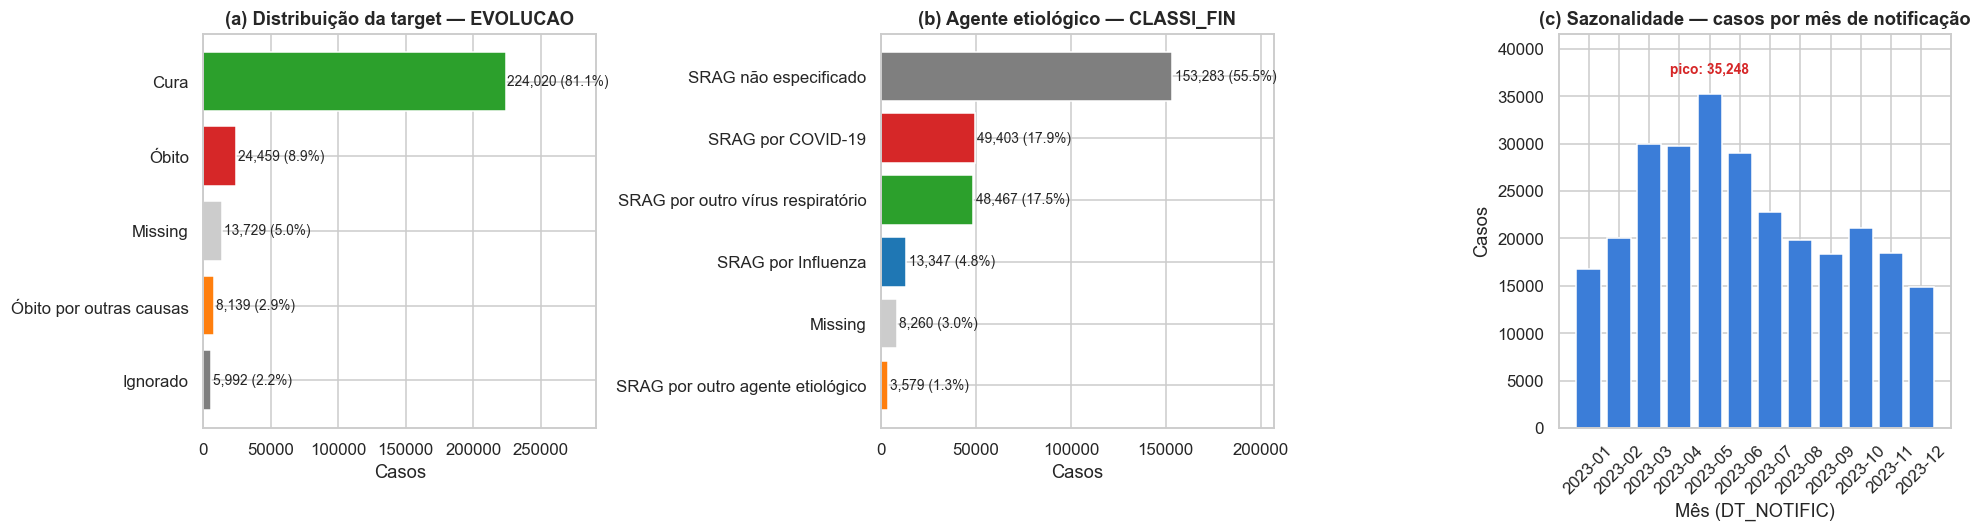

Salva: reports\figures\03_eda\01_visao_geral.png

Mês de pico: 2023-05 com 35,248 casos
Mês de vale: 2023-12 com 14,882 casos


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Distribuição da target
target_counts = df["EVOLUCAO_LABEL"].fillna("Missing").value_counts()
target_pct = target_counts / n_total * 100
colors_target = {
    "Cura": "#2ca02c", "Óbito": "#d62728",
    "Óbito por outras causas": "#ff7f0e", "Ignorado": "#7f7f7f",
    "Missing": "#cccccc",
}
bar_colors = [colors_target.get(str(k), "#1f77b4") for k in target_counts.index]
axes[0].barh(target_counts.index.astype(str), target_counts.values, color=bar_colors)
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(v + n_total * 0.005, i, f"{v:,} ({p:.1f}%)", va="center", fontsize=9)
axes[0].set_title("(a) Distribuição da target — EVOLUCAO")
axes[0].set_xlabel("Casos")
axes[0].set_xlim(0, target_counts.max() * 1.30)
axes[0].invert_yaxis()

# (b) Agente etiológico
agent_counts = df["CLASSI_FIN_LABEL"].fillna("Missing").value_counts()
agent_pct = agent_counts / n_total * 100
agent_bar_colors = [AGENT_COLORS.get(str(k), "#cccccc") for k in agent_counts.index]
axes[1].barh(agent_counts.index.astype(str), agent_counts.values, color=agent_bar_colors)
for i, (v, p) in enumerate(zip(agent_counts.values, agent_pct.values)):
    axes[1].text(v + n_total * 0.005, i, f"{v:,} ({p:.1f}%)", va="center", fontsize=9)
axes[1].set_title("(b) Agente etiológico — CLASSI_FIN")
axes[1].set_xlabel("Casos")
axes[1].set_xlim(0, agent_counts.max() * 1.35)
axes[1].invert_yaxis()

# (c) Sazonalidade mensal
monthly = df.groupby(df["DT_NOTIFIC"].dt.to_period("M")).size()
axes[2].bar(monthly.index.astype(str), monthly.values, color="#3b7dd8")
peak_idx = int(np.argmax(monthly.values))
axes[2].annotate(
    f"pico: {monthly.iloc[peak_idx]:,}",
    xy=(peak_idx, monthly.iloc[peak_idx]),
    xytext=(peak_idx, monthly.iloc[peak_idx] * 1.06),
    ha="center", fontsize=9, color="#d62728", weight="bold",
)
axes[2].set_title("(c) Sazonalidade — casos por mês de notificação")
axes[2].set_xlabel("Mês (DT_NOTIFIC)")
axes[2].set_ylabel("Casos")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, monthly.max() * 1.18)

plt.tight_layout()
fig_path = FIG_DIR / "01_visao_geral.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print(f"\nMês de pico: {monthly.idxmax()} com {monthly.max():,} casos")
print(f"Mês de vale: {monthly.idxmin()} com {monthly.min():,} casos")


**Leitura — composição e sazonalidade:**

- **Agente etiológico:** a categoria "SRAG não especificado" (cerca de 55%) indica que o laboratório não foi realizado ou foi inconclusivo. Análises por agente subestimam o efeito real de COVID, Influenza e outros, pois esses 55% diluem cada categoria. Não é bug, é a realidade do registro.
- **Sazonalidade mensal:** o pico identifica a temporada de maior carga assistencial. É insumo crítico para a Fase 7 (recomendações de saúde pública, com alocação de leitos UTI por sazonalidade) e para a Fase 4 (features sazonais).

## 3.2 — Tendências temporais

A semana epidemiológica é a unidade usada pelo Ministério da Saúde em boletins de vigilância. Captura a dinâmica de circulação viral em escala fina e permite identificar quando cada agente entra ou sai de circulação. O dataset já traz `SEM_NOT` (semana de notificação) preenchida pela ficha SIVEP, o que dispensa cálculo derivado.

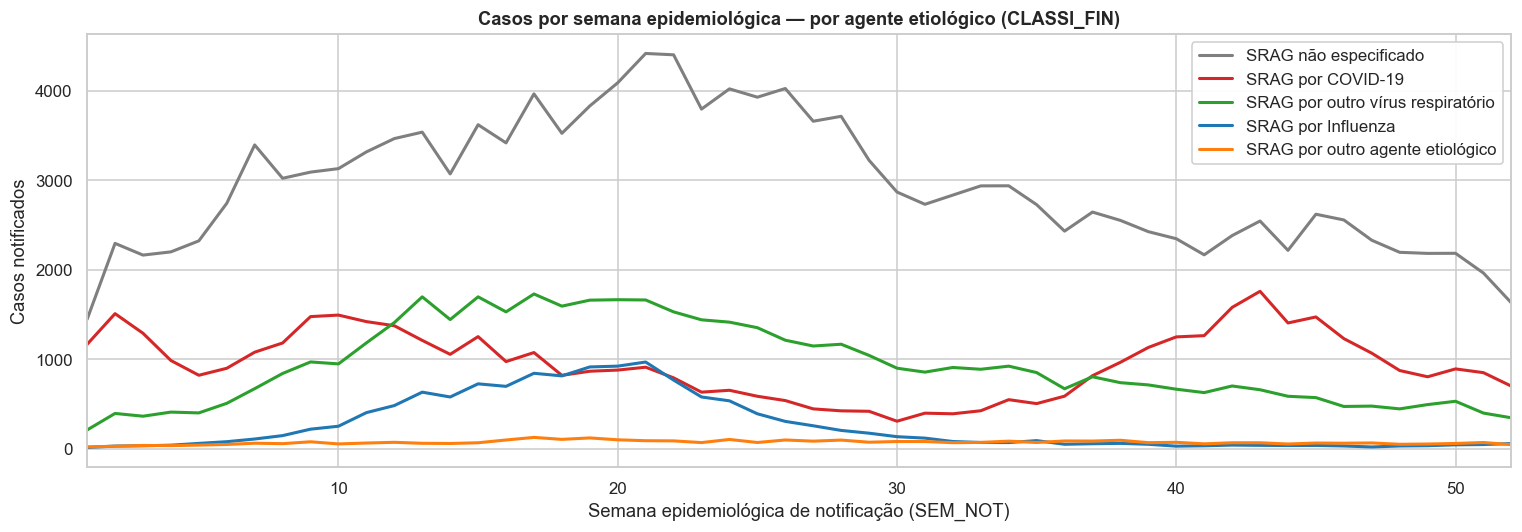

Salva: reports\figures\03_eda\02_series_semanais_agente.png

Semana de pico por agente (top-3 colunas mais frequentes):
  SRAG não especificado                    → SE 21 (4,419 casos no pico · 153,283 no ano)
  SRAG por COVID-19                        → SE 43 (1,759 casos no pico · 49,403 no ano)
  SRAG por outro vírus respiratório        → SE 17 (1,729 casos no pico · 48,467 no ano)
  SRAG por Influenza                       → SE 21 (  968 casos no pico · 13,347 no ano)
  SRAG por outro agente etiológico         → SE 17 (  125 casos no pico ·  3,579 no ano)


In [5]:
# Pivot: linhas = semana epi, colunas = agente, valores = contagem
weekly_by_agent = (
    df.dropna(subset=["CLASSI_FIN_LABEL"])
    .groupby(["SEM_NOT", "CLASSI_FIN_LABEL"])
    .size()
    .unstack(fill_value=0)
)
# Ordenar colunas pela ordem visual (mais frequente primeiro)
col_order = weekly_by_agent.sum().sort_values(ascending=False).index
weekly_by_agent = weekly_by_agent[col_order]

fig, ax = plt.subplots(figsize=(14, 5))
for col in weekly_by_agent.columns:
    ax.plot(
        weekly_by_agent.index, weekly_by_agent[col],
        label=col, color=AGENT_COLORS.get(col, "#888"), linewidth=2,
    )
ax.set_title("Casos por semana epidemiológica — por agente etiológico (CLASSI_FIN)")
ax.set_xlabel("Semana epidemiológica de notificação (SEM_NOT)")
ax.set_ylabel("Casos notificados")
ax.legend(loc="upper right", framealpha=0.95)
ax.set_xlim(weekly_by_agent.index.min(), weekly_by_agent.index.max())
plt.tight_layout()
fig_path = FIG_DIR / "02_series_semanais_agente.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print("\nSemana de pico por agente (top-3 colunas mais frequentes):")
for col in col_order[:5]:
    pk = int(weekly_by_agent[col].idxmax())
    pv = int(weekly_by_agent[col].max())
    tot = int(weekly_by_agent[col].sum())
    print(f"  {col:40s} → SE {pk:2d} ({pv:>5,} casos no pico · {tot:>6,} no ano)")


**Leitura — circulação viral em 2023:** os picos por agente revelam quando cada vírus dominou. A diferenciação temporal entre agentes é o que justifica análises por agente; um modelo de evolução que ignore o agente perde sinal sazonal específico. Para a Fase 4, uma feature `SEM_NOT` (ou flag binária de "alta temporada") provavelmente carrega sinal independente de idade e comorbidade, e vale testar.

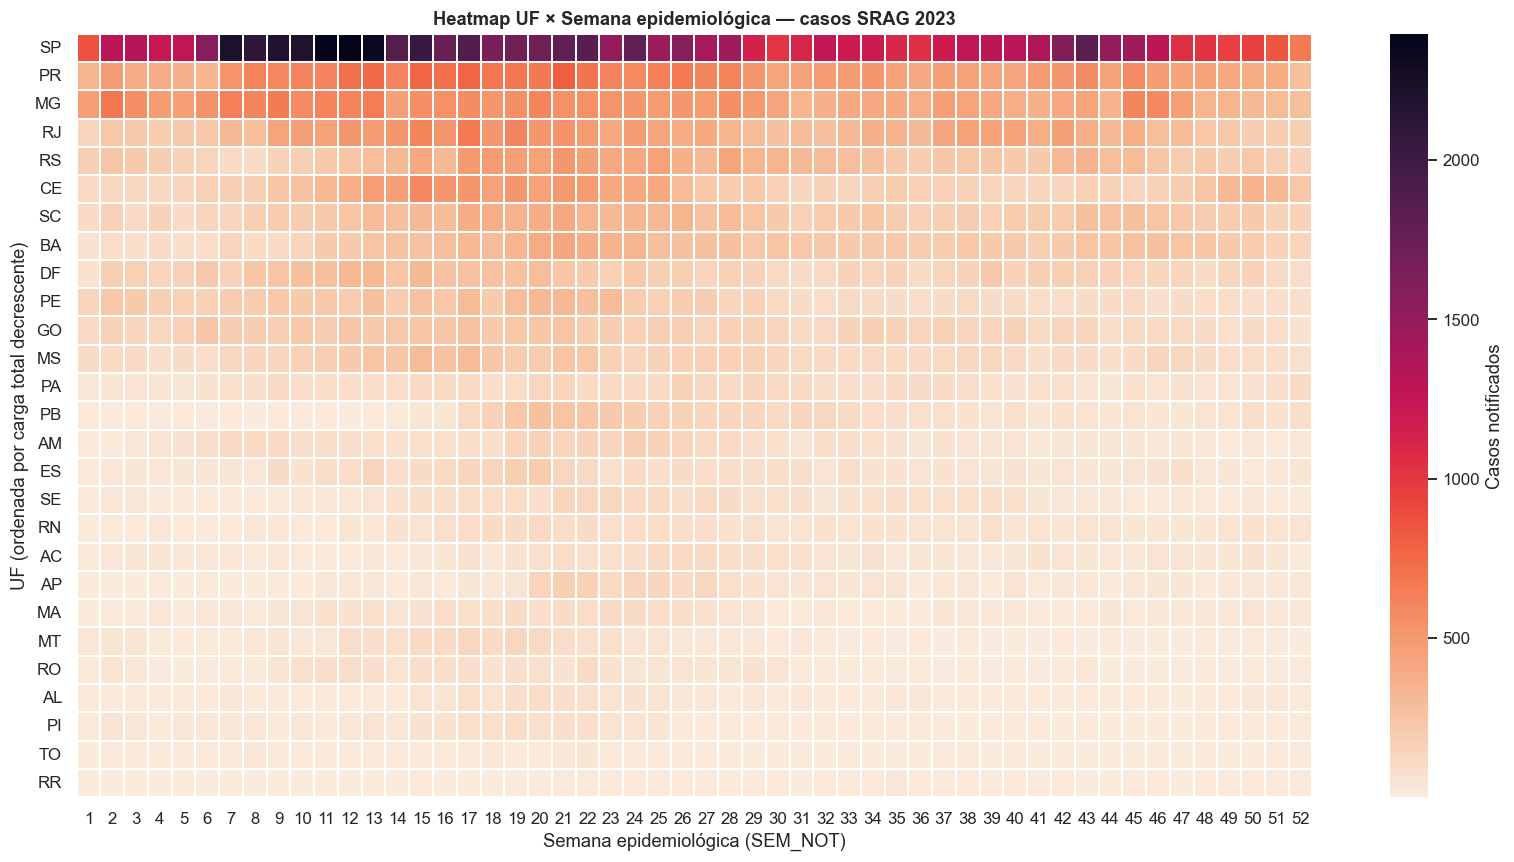

Salva: reports\figures\03_eda\03_heatmap_uf_semana.png


In [6]:
# Heatmap UF × semana — intensidade = casos
uf_col = "SG_UF"
heat_df = df.dropna(subset=[uf_col]).copy()
heat_df[uf_col] = heat_df[uf_col].astype("string").str.upper()

heat = (
    heat_df.groupby([uf_col, "SEM_NOT"])
    .size()
    .unstack(fill_value=0)
)
# Ordenar UFs por carga total (mais alta no topo)
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(
    heat, cmap="rocket_r", cbar_kws={"label": "Casos notificados"},
    linewidths=0.2, linecolor="white", ax=ax,
)
ax.set_title("Heatmap UF × Semana epidemiológica — casos SRAG 2023")
ax.set_xlabel("Semana epidemiológica (SEM_NOT)")
ax.set_ylabel("UF (ordenada por carga total decrescente)")
plt.tight_layout()
fig_path = FIG_DIR / "03_heatmap_uf_semana.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")


**Leitura — heatmap UF × semana:**

- Eixo vertical: UFs ordenadas por carga total. As 3 ou 4 do topo concentram a maior parte dos casos do ano.
- Bandas verticais escuras indicam semanas de surto sincronizado entre UFs (típico de circulação viral nacional).
- Faixas horizontais persistentes revelam UFs com circulação contínua durante o ano; faixas em "ondas" curtas mostram surtos concentrados.

Para a Fase 7, o alerta antecipado precisa olhar as UFs do topo (alto sinal estatístico) para puxar o gatilho operacional para o restante do país.

## 3.3 — Distribuição geográfica

O objetivo deste recorte é identificar onde o problema é maior, em valores absolutos (para alocação de recursos) e em letalidade observada (para selecionar alvos de melhoria de qualidade hospitalar).

Há uma limitação metodológica reconhecida: sem `geopandas` instalado e sem dados populacionais (IBGE), não há mapa coroplético nem normalização por 100 mil habitantes nesta entrega. Os rankings absolutos e as taxas observadas são suficientes para a leitura epidemiológica; um coroplético poderia entrar como upgrade na apresentação final.

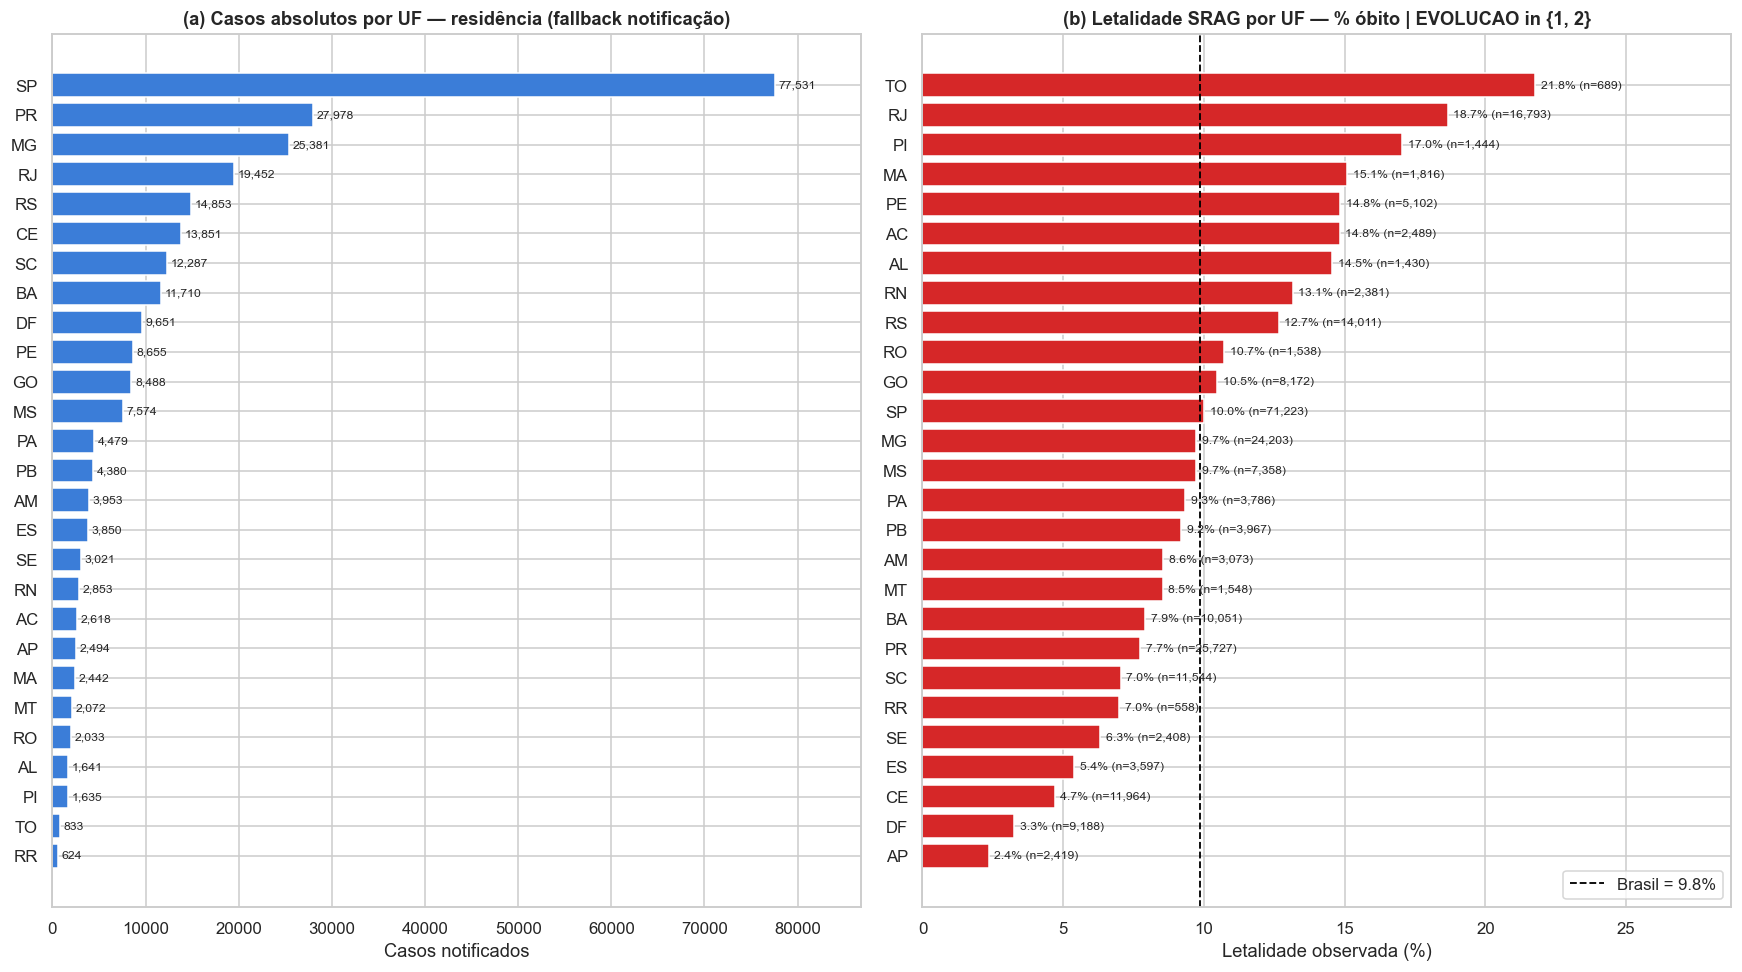

Salva: reports\figures\03_eda\04_geografia_uf.png

Letalidade — top/bottom 5 UFs (mín. 100 casos com desfecho):
Maior letalidade:
         n  obitos  letalidade_pct
_UF                               
PE    5102     757           14.84
MA    1816     274           15.09
PI    1444     246           17.04
RJ   16793    3134           18.66
TO     689     150           21.77

Menor letalidade:
         n  obitos  letalidade_pct
_UF                               
AP    2419      57            2.36
DF    9188     299            3.25
CE   11964     562            4.70
ES    3597     194            5.39
SE    2408     152            6.31


In [7]:
# UF efetiva: residência (SG_UF) com fallback para notificação (SG_UF_NOT)
uf = df["SG_UF"].astype("string").str.upper()
uf = uf.fillna(df["SG_UF_NOT"].astype("string").str.upper())
uf_counts = uf.value_counts().sort_values(ascending=True)

# Letalidade observada por UF — apenas casos com EVOLUCAO ∈ {1, 2}
df_uf = df.assign(_UF=uf)
mask_mod = df_uf["EVOLUCAO"].isin([1, 2])
let_uf = (
    df_uf.loc[mask_mod]
    .groupby("_UF")
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
let_uf["letalidade_pct"] = let_uf["obitos"] / let_uf["n"] * 100
let_uf = let_uf.sort_values("letalidade_pct", ascending=True)

br_let = (df["EVOLUCAO"] == 2).sum() / df["EVOLUCAO"].isin([1, 2]).sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# (a) Casos absolutos por UF
axes[0].barh(uf_counts.index.astype(str), uf_counts.values, color="#3b7dd8")
for i, v in enumerate(uf_counts.values):
    axes[0].text(v + uf_counts.max() * 0.005, i, f"{v:,}", va="center", fontsize=8)
axes[0].set_title("(a) Casos absolutos por UF — residência (fallback notificação)")
axes[0].set_xlabel("Casos notificados")
axes[0].set_xlim(0, uf_counts.max() * 1.12)

# (b) Letalidade observada por UF
axes[1].barh(let_uf.index.astype(str), let_uf["letalidade_pct"].values, color="#d62728")
axes[1].axvline(br_let, color="black", linestyle="--", linewidth=1.2,
                label=f"Brasil = {br_let:.1f}%")
for i, (v, n) in enumerate(zip(let_uf["letalidade_pct"].values, let_uf["n"].values)):
    axes[1].text(v + 0.2, i, f"{v:.1f}% (n={n:,})", va="center", fontsize=8)
axes[1].set_title("(b) Letalidade SRAG por UF — % óbito | EVOLUCAO in {1, 2}")
axes[1].set_xlabel("Letalidade observada (%)")
axes[1].set_xlim(0, let_uf["letalidade_pct"].max() * 1.32)
axes[1].legend(loc="lower right")

plt.tight_layout()
fig_path = FIG_DIR / "04_geografia_uf.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print("\nLetalidade — top/bottom 5 UFs (mín. 100 casos com desfecho):")
let_uf_filt = let_uf[let_uf["n"] >= 100]
print("Maior letalidade:")
print(let_uf_filt.tail(5)[["n", "obitos", "letalidade_pct"]].round(2).to_string())
print("\nMenor letalidade:")
print(let_uf_filt.head(5)[["n", "obitos", "letalidade_pct"]].round(2).to_string())


**Leitura — assimetria UF:**

- A carga absoluta concentra-se nas UFs mais populosas (Sudeste e Sul), em efeito direto de denominador populacional. Sem normalização por 100 mil habitantes, este ranking serve mais para alocação de recursos do que para mensurar risco populacional.
- A letalidade observada varia substancialmente entre UFs (a linha tracejada representa a média Brasil). A variação é confundida por (1) tamanho amostral em UFs pequenas (o ranking filtra n maior ou igual a 100), (2) perfil de gravidade (idade, comorbidade e vacinação) e (3) qualidade do registro de desfecho (UFs com mais "Ignorado" subestimam a letalidade real).

Para a Fase 4, a UF entra como feature, mas o modelo precisa controlar idade e comorbidade para que a contribuição da UF seja interpretável. Uma alternativa é usar `REGIAO_BR` (5 categorias, mais robusta a UFs pequenas).

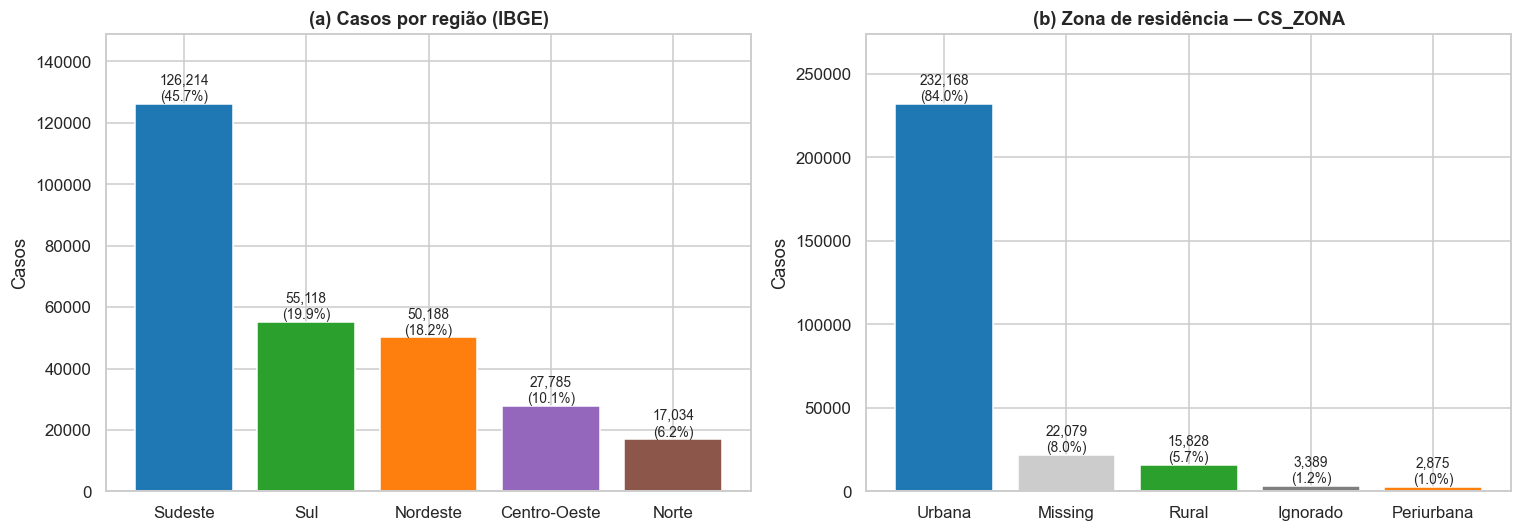

Salva: reports\figures\03_eda\05_regiao_zona.png

Letalidade por zona (apenas EVOLUCAO ∈ {1, 2}, n ≥ 100):


                    n  obitos  letalidade_pct
CS_ZONA_LABEL                                
Ignorado         3054     345           11.30
Rural           13288    1484           11.17
<NA>            18826    1929           10.25
Urbana         210599   20621            9.79
Periurbana       2712      80            2.95


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Casos por região IBGE
reg = df["REGIAO_BR"].fillna("Missing").value_counts()
reg_pct = reg / reg.sum() * 100
colors_reg = {
    "Sudeste": "#1f77b4", "Sul": "#2ca02c", "Nordeste": "#ff7f0e",
    "Centro-Oeste": "#9467bd", "Norte": "#8c564b", "Missing": "#cccccc",
}
bar_colors = [colors_reg.get(str(k), "#3b7dd8") for k in reg.index]
bars = axes[0].bar(reg.index.astype(str), reg.values, color=bar_colors)
for bar, v, p in zip(bars, reg.values, reg_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({p:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("(a) Casos por região (IBGE)")
axes[0].set_ylabel("Casos")
axes[0].set_ylim(0, reg.max() * 1.18)

# (b) CS_ZONA — rural vs urbano
zona = df["CS_ZONA_LABEL"].fillna("Missing").value_counts()
zona_pct = zona / zona.sum() * 100
colors_zona = {
    "Urbana": "#1f77b4", "Rural": "#2ca02c", "Periurbana": "#ff7f0e",
    "Ignorado": "#7f7f7f", "Missing": "#cccccc",
}
bar_colors_z = [colors_zona.get(str(k), "#3b7dd8") for k in zona.index]
bars = axes[1].bar(zona.index.astype(str), zona.values, color=bar_colors_z)
for bar, v, p in zip(bars, zona.values, zona_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({p:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title("(b) Zona de residência — CS_ZONA")
axes[1].set_ylabel("Casos")
axes[1].set_ylim(0, zona.max() * 1.18)

plt.tight_layout()
fig_path = FIG_DIR / "05_regiao_zona.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

# Letalidade por zona — cruzamento útil para a próxima Fase
print("\nLetalidade por zona (apenas EVOLUCAO ∈ {1, 2}, n ≥ 100):")
zona_let = (
    df[df["EVOLUCAO"].isin([1, 2])]
    .groupby("CS_ZONA_LABEL", dropna=False)
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
zona_let["letalidade_pct"] = zona_let["obitos"] / zona_let["n"] * 100
zona_let = zona_let[zona_let["n"] >= 100].sort_values("letalidade_pct", ascending=False)
print(zona_let.round(2).to_string())


**Leitura — região e zona:**

- **Região:** o Sudeste concentra a maior parte dos casos absolutos, seguido de Sul e Nordeste — esperado pelo perfil populacional e pela infraestrutura de notificação. `REGIAO_BR` é uma feature mais robusta que UF para o modelo (5 categorias estáveis contra 27 com tamanhos muito variáveis).
- **Zona:** dominância urbana, esperada porque a SRAG é predominantemente notificada em hospitais que ficam em áreas urbanas (mesmo pacientes rurais acabam categorizados pela cidade onde foram internados).
- **Letalidade por zona:** após o filtro de n maior ou igual a 100, as taxas observadas tendem a ser próximas. Isso sugere que o desfecho não depende fortemente do tipo de área em si, mas das variáveis clínicas e demográficas a ela correlacionadas.

## 3.4 — Demografia

Idade, sexo, raça/cor e escolaridade são determinantes sociais clássicos com efeito conhecido em desfechos de SRAG. A Fase 4 utilizará várias dessas variáveis como features; aqui, mede-se a distribuição base e a magnitude do gradiente de letalidade por desfecho.

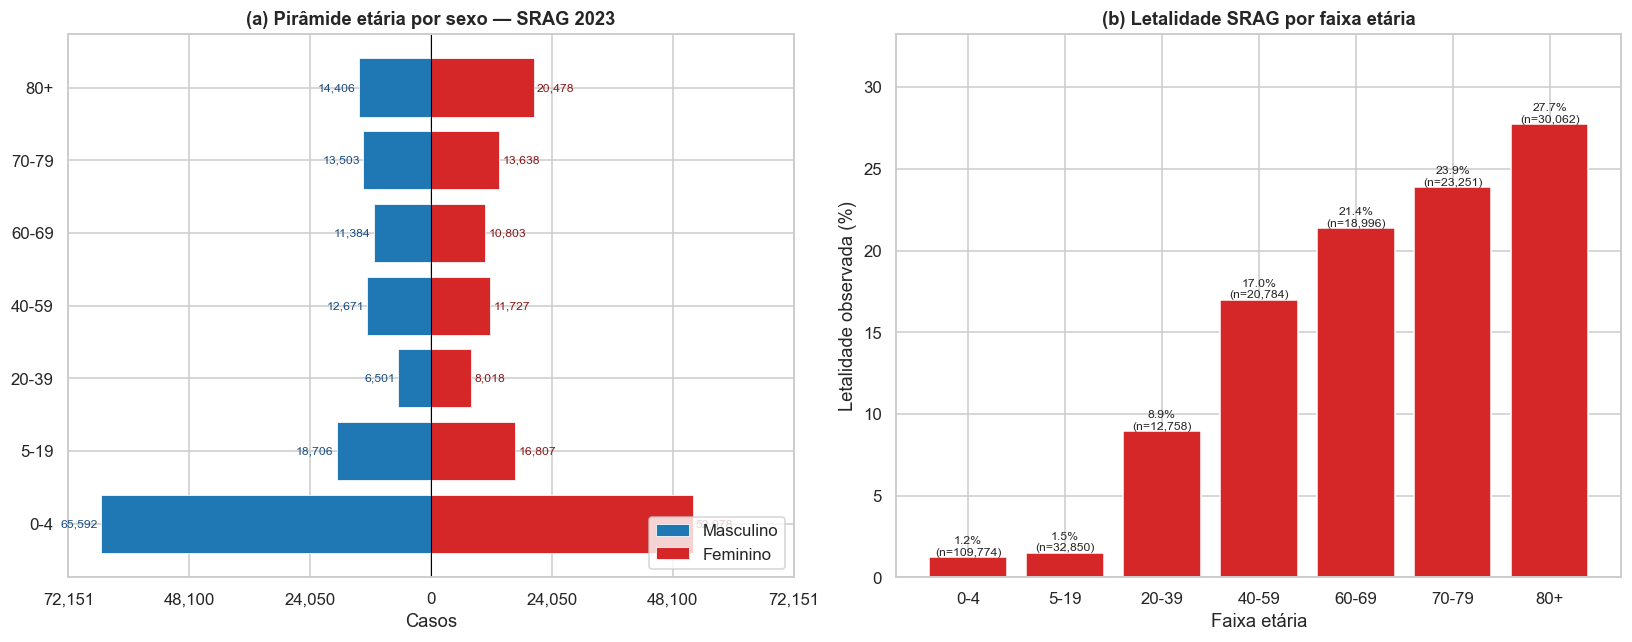

Salva: reports\figures\03_eda\06_demografia_idade_sexo.png

Letalidade por faixa etária:
                   n  obitos  letalidade_pct
FAIXA_ETARIA                                
0-4           109774    1358            1.24
5-19           32850     492            1.50
20-39          12758    1140            8.94
40-59          20784    3531           16.99
60-69          18996    4057           21.36
70-79          23251    5547           23.86
80+            30062    8333           27.72


In [9]:
# Pirâmide etária por sexo (Masc à esquerda, Fem à direita)
df_pir = df[df["CS_SEXO_LABEL"].isin(["Masculino", "Feminino"])].copy()
pir = (
    df_pir.groupby(["FAIXA_ETARIA", "CS_SEXO_LABEL"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(cleaning.AGE_LABELS)
    .fillna(0)
)

# Letalidade por faixa etária
mod = df[df["EVOLUCAO"].isin([1, 2])]
let_age = (
    mod.groupby("FAIXA_ETARIA", observed=True)
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
    .reindex(cleaning.AGE_LABELS)
)
let_age["letalidade_pct"] = let_age["obitos"] / let_age["n"] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Pirâmide etária
y = np.arange(len(pir))
axes[0].barh(y, -pir["Masculino"].values, color="#1f77b4", label="Masculino",
             edgecolor="white", linewidth=0.5)
axes[0].barh(y, pir["Feminino"].values, color="#d62728", label="Feminino",
             edgecolor="white", linewidth=0.5)
axes[0].set_yticks(y)
axes[0].set_yticklabels(pir.index)
axes[0].set_xlabel("Casos")
axes[0].set_title("(a) Pirâmide etária por sexo — SRAG 2023")
axes[0].axvline(0, color="black", linewidth=0.7)
# Anotações com valores absolutos
for i, (m, f) in enumerate(zip(pir["Masculino"].values, pir["Feminino"].values)):
    axes[0].text(-m - max(pir.max()) * 0.01, i, f"{int(m):,}", ha="right", va="center", fontsize=8, color="#1f4f80")
    axes[0].text(f + max(pir.max()) * 0.01, i, f"{int(f):,}", ha="left", va="center", fontsize=8, color="#8a1a1a")
# Ticks simétricos com rótulos absolutos
max_abs = max(pir["Masculino"].max(), pir["Feminino"].max())
xticks = np.linspace(-max_abs * 1.1, max_abs * 1.1, 7)
axes[0].set_xticks(xticks)
axes[0].set_xticklabels([f"{int(abs(t)):,}" for t in xticks])
axes[0].legend(loc="lower right")

# (b) Letalidade por faixa etária
bars = axes[1].bar(let_age.index.astype(str), let_age["letalidade_pct"], color="#d62728")
for bar, v, n in zip(bars, let_age["letalidade_pct"], let_age["n"]):
    if pd.notna(v):
        axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}%\n(n={int(n):,})",
                     ha="center", va="bottom", fontsize=8)
axes[1].set_title("(b) Letalidade SRAG por faixa etária")
axes[1].set_xlabel("Faixa etária")
axes[1].set_ylabel("Letalidade observada (%)")
axes[1].set_ylim(0, let_age["letalidade_pct"].max() * 1.20)

plt.tight_layout()
fig_path = FIG_DIR / "06_demografia_idade_sexo.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print("\nLetalidade por faixa etária:")
print(let_age[["n", "obitos", "letalidade_pct"]].round(2).to_string())


**Leitura — gradiente etário e sexo:**

- A "pirâmide" tem o padrão bimodal esperado: amplo grupo de 0-4 anos (VSR pediátrico, cerca de 42% dos casos) e amplo grupo de idosos (COVID e Influenza). Não é uma pirâmide demográfica típica, mas um perfil epidemiológico de doenças respiratórias graves em 2023.
- A letalidade cresce monotonicamente com a idade, em gradiente clássico, com salto acentuado a partir dos 60 anos. A mensagem para a Fase 4 é direta: `IDADE_ANOS` contínua (ou `FAIXA_ETARIA` ordinal) é, provavelmente, a feature mais preditiva isoladamente.
- A distribuição por sexo é relativamente equilibrada nas faixas extremas (crianças e idosos), com leve predominância masculina em adultos jovens. Vale testar `CS_SEXO` no modelo, ainda que o efeito esperado seja menor.

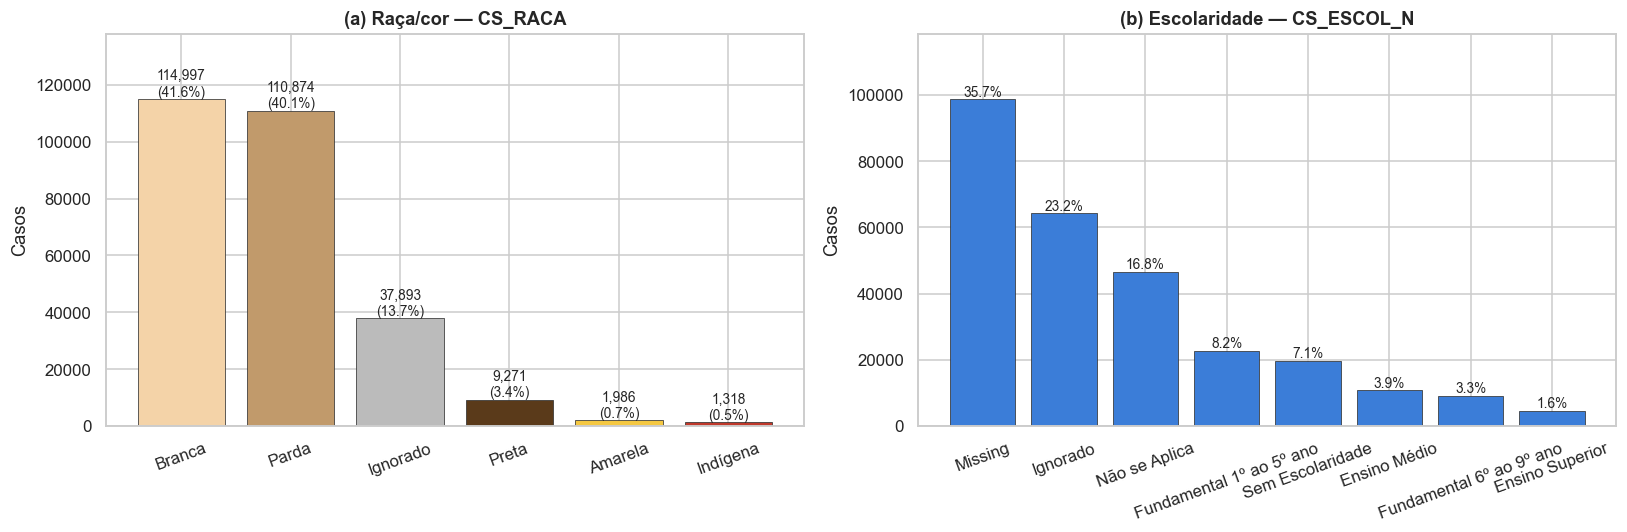

Salva: reports\figures\03_eda\07_demografia_raca_escolaridade.png



Letalidade por raça/cor (n ≥ 100):
                    n  obitos  letalidade_pct
CS_RACA_LABEL                                
Amarela          1783     269           15.09
Preta            8244    1227           14.88
Branca         105660   11489           10.87
Parda           98695    9201            9.32
Indígena         1121      91            8.12
Ignorado        32976    2182            6.62


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Raça/cor
raca = df["CS_RACA_LABEL"].fillna("Missing").value_counts()
raca_pct = raca / len(df) * 100
colors_raca = {
    "Branca": "#f4d3a8", "Preta": "#5a3a1a", "Amarela": "#f5c842",
    "Parda": "#c19a6b", "Indígena": "#c0392b", "Ignorado": "#bbbbbb",
    "Missing": "#dddddd",
}
bar_colors = [colors_raca.get(str(k), "#888") for k in raca.index]
bars = axes[0].bar(raca.index.astype(str), raca.values, color=bar_colors, edgecolor="#333", linewidth=0.5)
for bar, v, p in zip(bars, raca.values, raca_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({p:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("(a) Raça/cor — CS_RACA")
axes[0].set_ylabel("Casos")
axes[0].set_ylim(0, raca.max() * 1.20)
axes[0].tick_params(axis="x", rotation=20)

# (b) Escolaridade
esc = df["CS_ESCOL_N_LABEL"].fillna("Missing").value_counts()
esc_pct = esc / len(df) * 100
bars = axes[1].bar(esc.index.astype(str), esc.values, color="#3b7dd8", edgecolor="#333", linewidth=0.5)
for bar, v, p in zip(bars, esc.values, esc_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f"{p:.1f}%",
                 ha="center", va="bottom", fontsize=9)
axes[1].set_title("(b) Escolaridade — CS_ESCOL_N")
axes[1].set_ylabel("Casos")
axes[1].set_ylim(0, esc.max() * 1.20)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
fig_path = FIG_DIR / "07_demografia_raca_escolaridade.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

# Letalidade por raça/cor — cruzamento útil para Fase 4 + Fase 7
let_raca = (
    df[df["EVOLUCAO"].isin([1, 2])]
    .groupby("CS_RACA_LABEL", dropna=False)
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
let_raca["letalidade_pct"] = let_raca["obitos"] / let_raca["n"] * 100
let_raca = let_raca[let_raca["n"] >= 100].sort_values("letalidade_pct", ascending=False)
print("\nLetalidade por raça/cor (n ≥ 100):")
print(let_raca.round(2).to_string())


**Leitura — raça/cor e escolaridade:**

- **Raça/cor:** a distribuição reflete tanto a composição populacional brasileira quanto desigualdades de acesso ao sistema. A categoria `Ignorado`/`Missing` permanece substancial, em problema crônico de qualidade da ficha SIVEP. Diferenças de letalidade entre grupos (impressa acima) são insumo para a análise de viés na Fase 6 (avaliação) e para recomendações de equidade na Fase 7.
- **Escolaridade:** a dominância de `Não se Aplica` é esperada, dado que 42% dos casos são crianças com menos de 5 anos. Para outros pacientes, a escolaridade carrega sinal socioeconômico, mas exige tratamento especial na Fase 4 (missing como categoria ou imputação com indicador).

## 3.5 — Sintomatologia

A prevalência ajuda a entender o quadro clínico predominante; a correlação entre sintomas identifica clusters (febre + tosse, dispneia + desconforto + saturação) que podem virar features compostas na Fase 4 (score de gravidade respiratória).

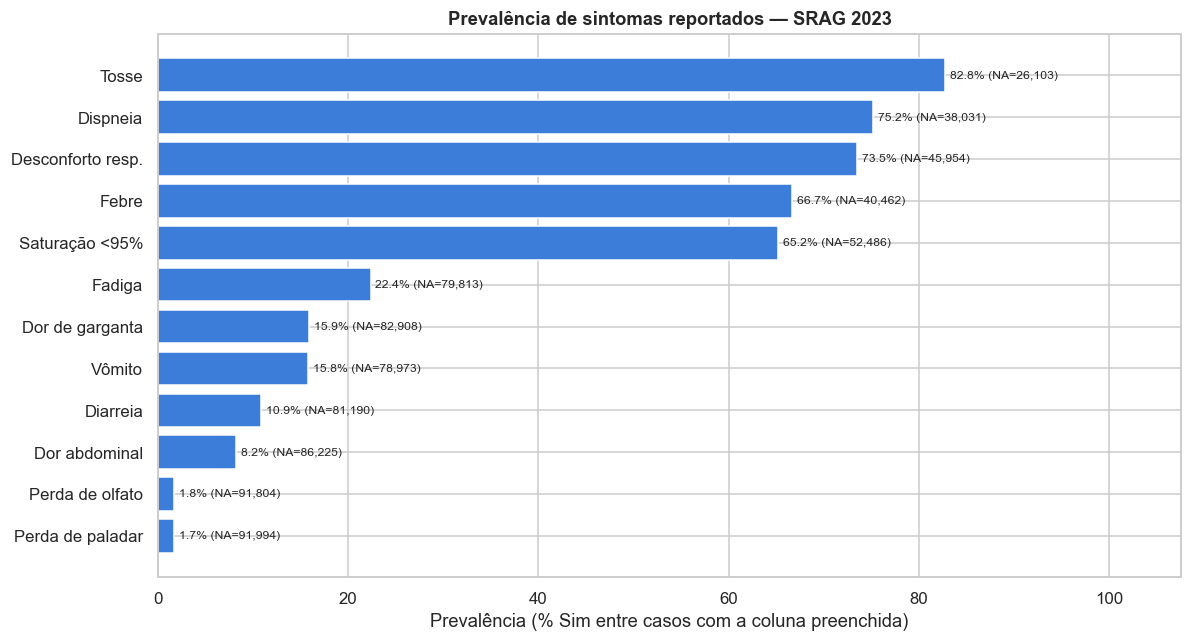

Salva: reports\figures\03_eda\08_sintomas_prevalencia.png


In [11]:
SYMPTOMS = ["FEBRE", "TOSSE", "GARGANTA", "DISPNEIA", "DESC_RESP", "SATURACAO",
            "DIARREIA", "VOMITO", "DOR_ABD", "FADIGA", "PERD_OLFT", "PERD_PALA"]
SYMPTOM_LABELS = {
    "FEBRE": "Febre", "TOSSE": "Tosse", "GARGANTA": "Dor de garganta",
    "DISPNEIA": "Dispneia", "DESC_RESP": "Desconforto resp.",
    "SATURACAO": "Saturação <95%", "DIARREIA": "Diarreia",
    "VOMITO": "Vômito", "DOR_ABD": "Dor abdominal", "FADIGA": "Fadiga",
    "PERD_OLFT": "Perda de olfato", "PERD_PALA": "Perda de paladar",
}

# Prevalência = % "Sim" entre não-missing
prev = []
for sym in SYMPTOMS:
    if sym not in df.columns:
        continue
    s = df[sym].dropna()
    if len(s) > 0:
        prev.append({
            "sintoma": SYMPTOM_LABELS[sym],
            "col": sym,
            "prevalencia_pct": float(s.mean()) * 100,
            "n_validos": len(s),
            "n_missing": int(df[sym].isna().sum()),
        })
prev_df = pd.DataFrame(prev).sort_values("prevalencia_pct", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(prev_df["sintoma"], prev_df["prevalencia_pct"], color="#3b7dd8")
for i, (v, miss) in enumerate(zip(prev_df["prevalencia_pct"], prev_df["n_missing"])):
    ax.text(v + 0.5, i, f"{v:.1f}% (NA={miss:,})", va="center", fontsize=8)
ax.set_xlabel("Prevalência (% Sim entre casos com a coluna preenchida)")
ax.set_title("Prevalência de sintomas reportados — SRAG 2023")
ax.set_xlim(0, prev_df["prevalencia_pct"].max() * 1.30)
plt.tight_layout()
fig_path = FIG_DIR / "08_sintomas_prevalencia.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")


**Leitura — prevalência:**

- Tosse e febre dominam o quadro clínico clássico de SRAG. A combinação dos dois define o portão de entrada da definição operacional.
- Atenção ao missing por sintoma: colunas adicionadas pós-COVID (perda de olfato e paladar) têm mais NA porque vários casos foram registrados em fichas antigas. Em modelos, pode-se (1) imputar como "não tem" se a ficha foi razoavelmente preenchida em geral, ou (2) criar um indicador binário de missing como feature auxiliar.

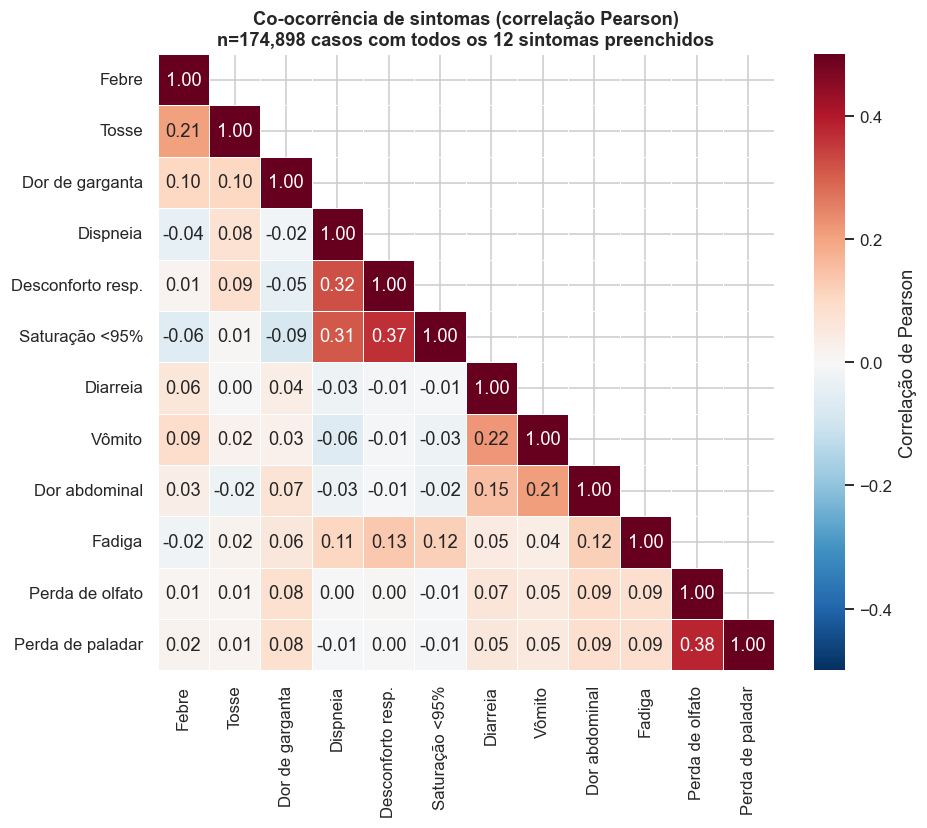

Salva: reports\figures\03_eda\09_sintomas_correlacao.png

Top 5 pares com maior correlação positiva:
Perda de olfato    Perda de paladar     0.379041
Desconforto resp.  Saturação <95%       0.365380
Dispneia           Desconforto resp.    0.322400
                   Saturação <95%       0.311242
Diarreia           Vômito               0.221774

Top 5 pares com maior correlação negativa:
Perda de paladar  Vômito             NaN
                  Dor abdominal      NaN
                  Fadiga             NaN
                  Perda de olfato    NaN
                  Perda de paladar   NaN


In [12]:
# Correlação Pearson entre sintomas — só com casos COM TODOS os sintomas preenchidos
# (evita NaN inflando correlação artificialmente)
sym_data = df[SYMPTOMS].rename(columns=SYMPTOM_LABELS).dropna()

corr = sym_data.corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap="RdBu_r", vmin=-0.5, vmax=0.5, center=0,
    annot=True, fmt=".2f", square=True, linewidths=0.5,
    cbar_kws={"label": "Correlação de Pearson"}, ax=ax,
)
ax.set_title(f"Co-ocorrência de sintomas (correlação Pearson)\n"
             f"n={len(sym_data):,} casos com todos os 12 sintomas preenchidos")
plt.tight_layout()
fig_path = FIG_DIR / "09_sintomas_correlacao.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

# Top pares correlacionados (off-diagonal absoluta)
print("\nTop 5 pares com maior correlação positiva:")
corr_un = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack().sort_values(ascending=False)
print(corr_un.head(5).to_string())
print("\nTop 5 pares com maior correlação negativa:")
print(corr_un.tail(5).to_string())


**Leitura — co-ocorrência:**

- Pares com correlação positiva forte indicam clusters clínicos (tipicamente dispneia, desconforto respiratório e saturação formam o "tripé respiratório" da SRAG grave). São candidatos a feature composta na Fase 4 (por exemplo, `RESP_SEVERIDADE = DISPNEIA OR DESC_RESP OR SATURACAO`).
- Pares fracos ou negativos sinalizam sintomas independentes, e cada um deve ser mantido separado no modelo.
- Vale a ressalva: a correlação aqui é entre presença reportada, não entre gravidade. Uma feature composta deve refletir a clínica, sem substituir o sinal individual de cada sintoma.

## 3.6 — Comorbidades

Comorbidades são os principais fatores de risco modificáveis para óbito por SRAG. A estratificação por desfecho identifica quais condições mais aumentam a letalidade, em insumo direto para o "top 5 fatores de risco" da Fase 7 e para a importância de features na Fase 6 (SHAP).

Vale o aviso metodológico: as letalidades observadas aqui não controlam confundidores (idade, agente e vacinação). Comorbidades comuns em idosos vão herdar parte do risco etário; o efeito independente só sai com modelo multivariado nas Fases 5 e 6.

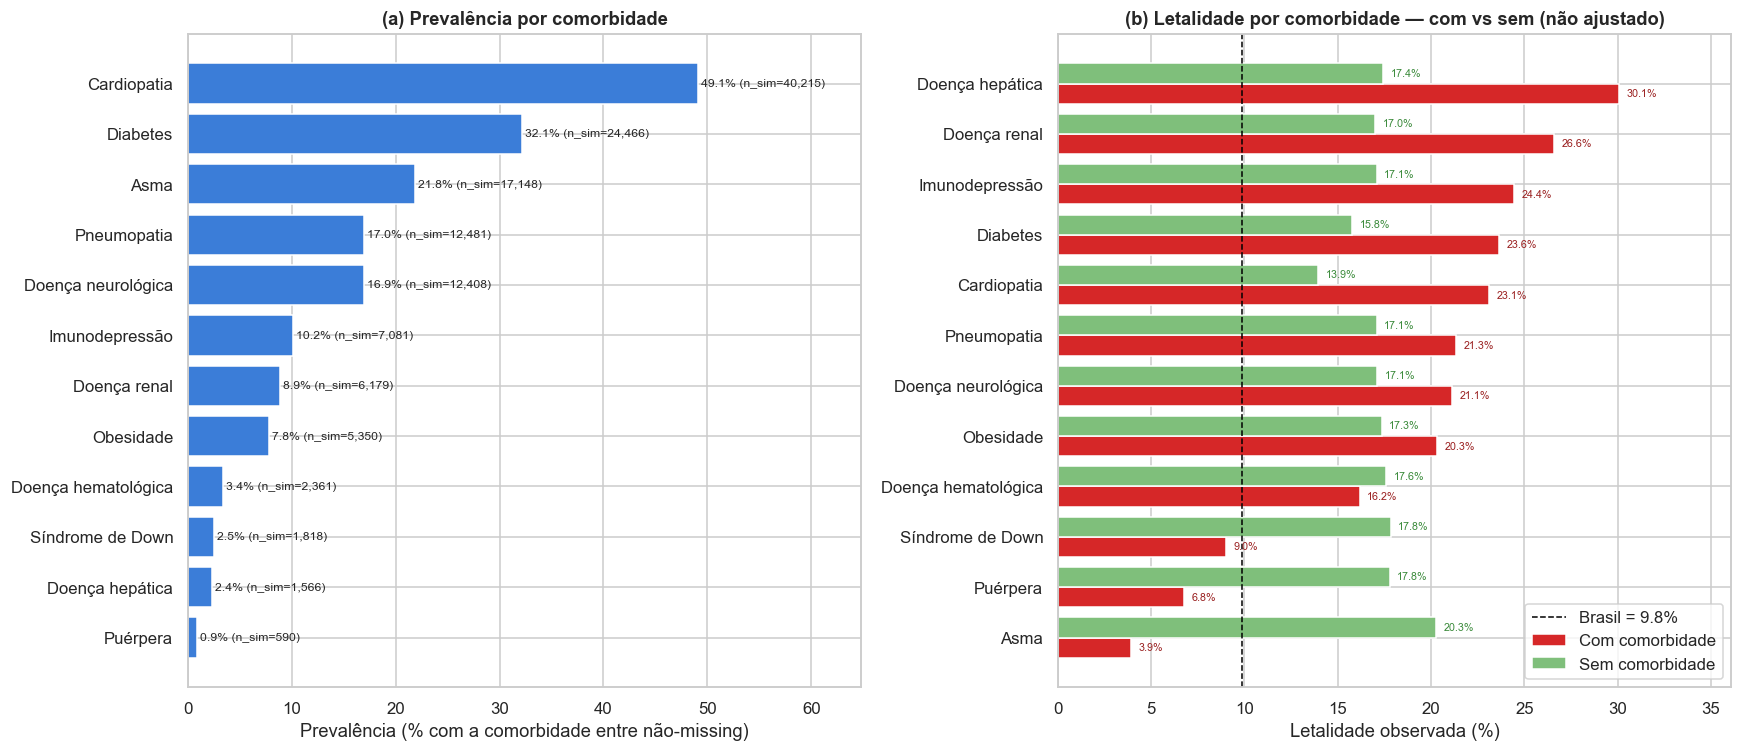

Salva: reports\figures\03_eda\10_comorbidades.png

Top 5 comorbidades por letalidade observada (não ajustada):
    comorbidade  prevalencia_pct  letalidade_sim  letalidade_nao  diff_let
Doença hepática             2.37           30.08           17.43     12.65
   Doença renal             8.86           26.61           17.00      9.61
 Imunodepressão            10.16           24.45           17.09      7.36
       Diabetes            32.13           23.63           15.77      7.86
    Cardiopatia            49.10           23.09           13.94      9.16

Top 5 comorbidades por diferença com-vs-sem (proxy de risco bruto):
    comorbidade  prevalencia_pct  letalidade_sim  letalidade_nao  diff_let
Doença hepática             2.37           30.08           17.43     12.65
   Doença renal             8.86           26.61           17.00      9.61
    Cardiopatia            49.10           23.09           13.94      9.16
       Diabetes            32.13           23.63           15.77      

In [13]:
COMORBID = ["CARDIOPATI", "DIABETES", "OBESIDADE", "IMUNODEPRE", "RENAL",
            "HEPATICA", "ASMA", "NEUROLOGIC", "PNEUMOPATI", "HEMATOLOGI",
            "SIND_DOWN", "PUERPERA"]
COMORBID_LABELS = {
    "CARDIOPATI": "Cardiopatia", "DIABETES": "Diabetes", "OBESIDADE": "Obesidade",
    "IMUNODEPRE": "Imunodepressão", "RENAL": "Doença renal",
    "HEPATICA": "Doença hepática", "ASMA": "Asma",
    "NEUROLOGIC": "Doença neurológica", "PNEUMOPATI": "Pneumopatia",
    "HEMATOLOGI": "Doença hematológica", "SIND_DOWN": "Síndrome de Down",
    "PUERPERA": "Puérpera",
}

mod = df[df["EVOLUCAO"].isin([1, 2])].copy()
results = []
for c in COMORBID:
    if c not in df.columns:
        continue
    s = df[c].dropna()
    prev_pct = float(s.mean()) * 100
    sub = mod[[c, "EVOLUCAO"]].dropna()
    let_sim = let_nao = np.nan
    n_sim = 0
    if len(sub) > 0:
        sub_sim = sub.loc[sub[c] == 1]
        sub_nao = sub.loc[sub[c] == 0]
        if len(sub_sim) > 0:
            let_sim = (sub_sim["EVOLUCAO"] == 2).mean() * 100
            n_sim = len(sub_sim)
        if len(sub_nao) > 0:
            let_nao = (sub_nao["EVOLUCAO"] == 2).mean() * 100
    results.append({
        "comorbidade": COMORBID_LABELS[c],
        "col": c,
        "prevalencia_pct": prev_pct,
        "letalidade_sim": let_sim,
        "letalidade_nao": let_nao,
        "diff_let": (let_sim - let_nao) if pd.notna(let_sim) and pd.notna(let_nao) else np.nan,
        "n_sim": n_sim,
    })
com_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) Prevalência geral, ordenada
prev_sort = com_df.sort_values("prevalencia_pct", ascending=True)
axes[0].barh(prev_sort["comorbidade"], prev_sort["prevalencia_pct"], color="#3b7dd8")
for i, (v, n) in enumerate(zip(prev_sort["prevalencia_pct"], prev_sort["n_sim"])):
    axes[0].text(v + 0.3, i, f"{v:.1f}% (n_sim={n:,})", va="center", fontsize=8)
axes[0].set_xlabel("Prevalência (% com a comorbidade entre não-missing)")
axes[0].set_title("(a) Prevalência por comorbidade")
axes[0].set_xlim(0, prev_sort["prevalencia_pct"].max() * 1.32)

# (b) Letalidade com vs sem, ordenado pela letalidade_sim
let_sort = com_df.sort_values("letalidade_sim", ascending=True)
br_let = (df["EVOLUCAO"] == 2).sum() / df["EVOLUCAO"].isin([1, 2]).sum() * 100
y = np.arange(len(let_sort))
height = 0.4
axes[1].barh(y - height / 2, let_sort["letalidade_sim"], height,
             color="#d62728", label="Com comorbidade")
axes[1].barh(y + height / 2, let_sort["letalidade_nao"], height,
             color="#7fbf7b", label="Sem comorbidade")
axes[1].axvline(br_let, color="black", linestyle="--", linewidth=1,
                label=f"Brasil = {br_let:.1f}%")
axes[1].set_yticks(y)
axes[1].set_yticklabels(let_sort["comorbidade"])
axes[1].set_xlabel("Letalidade observada (%)")
axes[1].set_title("(b) Letalidade por comorbidade — com vs sem (não ajustado)")
axes[1].legend(loc="lower right")
for i, (s_, n_) in enumerate(zip(let_sort["letalidade_sim"], let_sort["letalidade_nao"])):
    if pd.notna(s_):
        axes[1].text(s_ + 0.4, i - height / 2, f"{s_:.1f}%", va="center", fontsize=7, color="#9a2020")
    if pd.notna(n_):
        axes[1].text(n_ + 0.4, i + height / 2, f"{n_:.1f}%", va="center", fontsize=7, color="#3a8a3a")
axes[1].set_xlim(0, max(let_sort["letalidade_sim"].max(), let_sort["letalidade_nao"].max()) * 1.20)

plt.tight_layout()
fig_path = FIG_DIR / "10_comorbidades.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print("\nTop 5 comorbidades por letalidade observada (não ajustada):")
print(
    com_df.sort_values("letalidade_sim", ascending=False)
    .head(5)[["comorbidade", "prevalencia_pct", "letalidade_sim", "letalidade_nao", "diff_let"]]
    .round(2)
    .to_string(index=False)
)
print("\nTop 5 comorbidades por diferença com-vs-sem (proxy de risco bruto):")
print(
    com_df.sort_values("diff_let", ascending=False)
    .head(5)[["comorbidade", "prevalencia_pct", "letalidade_sim", "letalidade_nao", "diff_let"]]
    .round(2)
    .to_string(index=False)
)


**Leitura — fatores de risco modificáveis:**

- Comorbidades com maior letalidade absoluta entre quem tem a condição (imunodepressão, doença renal e neurológica) sinalizam grupos de alto risco para intervenção priorizada, em insumo direto para a Fase 7.
- A diferença "com" contra "sem" é o sinal bruto de risco, mas não controla idade. Diabetes e cardiopatia têm alta prevalência em idosos e parte do "efeito" é etário. As Fases 4 e 5 vão isolar o efeito independente via modelo multivariado.
- Para a apresentação final, comorbidades com alta prevalência e alta diferença (tipicamente cardiopatia, diabetes, doença renal e imunodepressão) são alvos prioritários, pois combinam impacto populacional e magnitude de risco.

## 3.7 — Vacinação COVID × evolução

Essa análise é central para a recomendação de saúde pública. Em 2023, SRAG por COVID-19 ainda representa cerca de 18% dos casos. Cruzar o status vacinal com a evolução nesse subgrupo testa o sinal de efetividade vacinal observado na base.

Há dois cuidados metodológicos importantes:

- Restringir a análise de letalidade vacinal ao subset COVID-19 (`CLASSI_FIN=5`), dado que vacinas anti-COVID não protegem contra Influenza ou VSR.
- O status vacinal "Sim" pode ser confundido por idade (idosos foram priorizados; a análise multivariada isola o efeito).

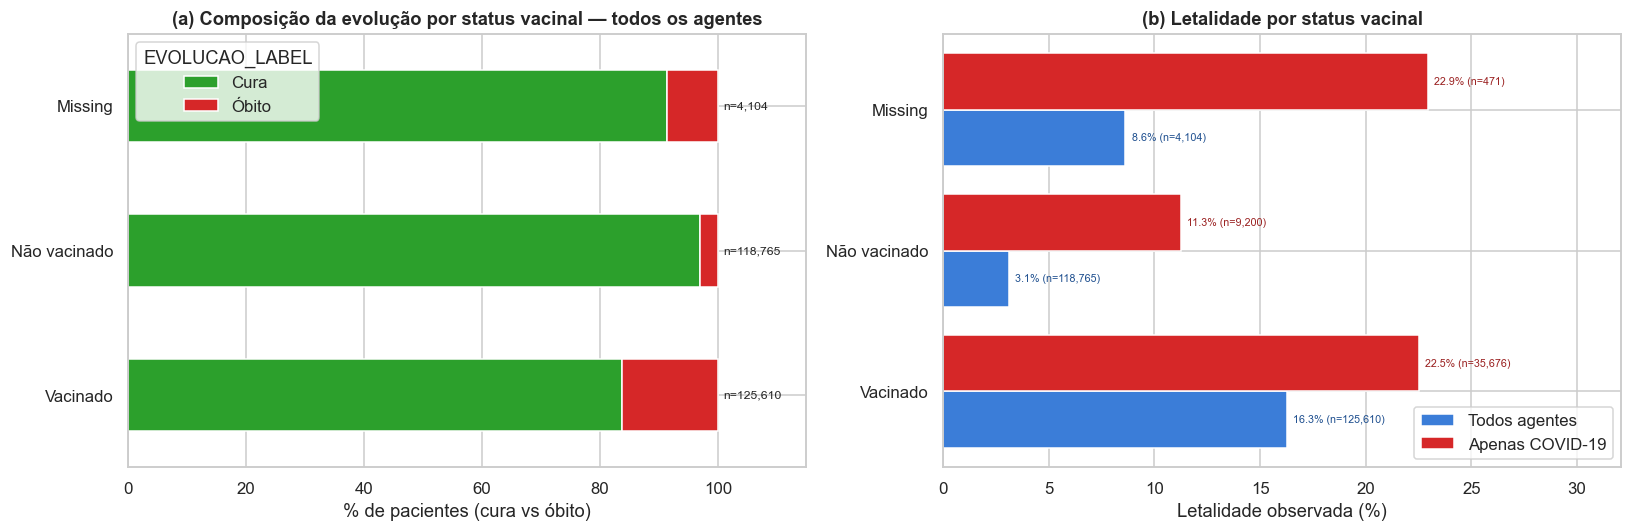

Salva: reports\figures\03_eda\11_vacinacao_covid.png

Letalidade por status vacinal (todos os agentes):
  Vacinado       : 16.26% (n=125,610)
  Não vacinado   : 3.10% (n=118,765)
  Missing        : 8.63% (n=4,104)

Letalidade por status vacinal (apenas SRAG por COVID-19):
  Vacinado       : 22.51% (n=35,676)
  Não vacinado   : 11.26% (n=9,200)
  Missing        : 22.93% (n=471)


In [14]:
# Status VACINA_COV (Sim/Não/Missing) × Evolução
vacc = df[df["EVOLUCAO"].isin([1, 2])].copy()
vacc["vac_status"] = vacc["VACINA_COV"].map({1.0: "Vacinado", 0.0: "Não vacinado"}).fillna("Missing")

cross = pd.crosstab(vacc["vac_status"], vacc["EVOLUCAO_LABEL"])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

let_all = vacc.groupby("vac_status")["EVOLUCAO"].apply(lambda s: (s == 2).mean() * 100)
covid_only = vacc[vacc["CLASSI_FIN"] == 5]
let_covid = covid_only.groupby("vac_status")["EVOLUCAO"].apply(lambda s: (s == 2).mean() * 100)
n_all = vacc.groupby("vac_status").size()
n_covid = covid_only.groupby("vac_status").size()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = ["Vacinado", "Não vacinado", "Missing"]
cross_pct = cross_pct.reindex(order).fillna(0)
# Garantir colunas Cura/Óbito existem
for col in ["Cura", "Óbito"]:
    if col not in cross_pct.columns:
        cross_pct[col] = 0
cross_pct[["Cura", "Óbito"]].plot(
    kind="barh", stacked=True, ax=axes[0],
    color=["#2ca02c", "#d62728"],
)
axes[0].set_title("(a) Composição da evolução por status vacinal — todos os agentes")
axes[0].set_xlabel("% de pacientes (cura vs óbito)")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 115)
for i, status in enumerate(order):
    n_status = int(cross.loc[status].sum()) if status in cross.index else 0
    axes[0].text(101, i, f"n={n_status:,}", va="center", fontsize=8)

# (b) Letalidade por status: todos vs COVID-only
y = np.arange(len(order))
h = 0.4
let_all_arr = [let_all.get(s, np.nan) for s in order]
let_covid_arr = [let_covid.get(s, np.nan) for s in order]
n_all_arr = [int(n_all.get(s, 0)) for s in order]
n_covid_arr = [int(n_covid.get(s, 0)) for s in order]
axes[1].barh(y - h / 2, let_all_arr, h, color="#3b7dd8", label="Todos agentes")
axes[1].barh(y + h / 2, let_covid_arr, h, color="#d62728", label="Apenas COVID-19")
axes[1].set_yticks(y)
axes[1].set_yticklabels(order)
axes[1].set_xlabel("Letalidade observada (%)")
axes[1].set_title("(b) Letalidade por status vacinal")
axes[1].legend(loc="lower right")
max_v = max([v for v in let_all_arr + let_covid_arr if pd.notna(v)])
axes[1].set_xlim(0, max_v * 1.40)
for i, (a_, c_, na_, nc_) in enumerate(zip(let_all_arr, let_covid_arr, n_all_arr, n_covid_arr)):
    if pd.notna(a_):
        axes[1].text(a_ + 0.3, i - h / 2, f"{a_:.1f}% (n={na_:,})",
                     va="center", fontsize=7, color="#1e4f8f")
    if pd.notna(c_):
        axes[1].text(c_ + 0.3, i + h / 2, f"{c_:.1f}% (n={nc_:,})",
                     va="center", fontsize=7, color="#9a2020")

plt.tight_layout()
fig_path = FIG_DIR / "11_vacinacao_covid.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print("\nLetalidade por status vacinal (todos os agentes):")
for s in order:
    if s in let_all.index:
        print(f"  {s:15s}: {let_all[s]:.2f}% (n={int(n_all[s]):,})")
print("\nLetalidade por status vacinal (apenas SRAG por COVID-19):")
for s in order:
    if s in let_covid.index:
        print(f"  {s:15s}: {let_covid[s]:.2f}% (n={int(n_covid[s]):,})")


**Leitura — vacinação (atenção: paradoxo de Simpson):**

Os números crus contam uma história aparentemente contraintuitiva — vacinados morrem mais que não vacinados:

- Todos os agentes: vacinados em 16,3% contra não vacinados em 3,1%.
- Apenas COVID-19: vacinados em 22,5% contra não vacinados em 11,3%.

Isso não significa que a vacina aumenta o risco. É um exemplo livro-texto de paradoxo de Simpson — confundimento por uma variável omitida, neste caso, a idade:

1. O PNI brasileiro priorizou a vacinação COVID em idosos e pessoas com comorbidades. O grupo "vacinados" é, em média, muito mais velho que o grupo "não vacinados".
2. A letalidade SRAG cresce monotonicamente com a idade (vide gráfico 3.4(b): 27,7% em 80+ contra 1,2% em 0-4).
3. O sinal etário domina o sinal vacinal nos cruzamentos simples.

Implicações para a Fase 5 e 6:

- O modelo multivariado com `IDADE_ANOS` (ou interação `IDADE_ANOS × VACINA_COV`) é obrigatório para isolar o efeito independente da vacina.
- A análise por subgrupo etário (estratificada) na Fase 6 deve confirmar o efeito protetor esperado dentro de cada faixa.
- Este achado entra na apresentação como exemplo concreto de por que modelos univariados não bastam em epidemiologia.

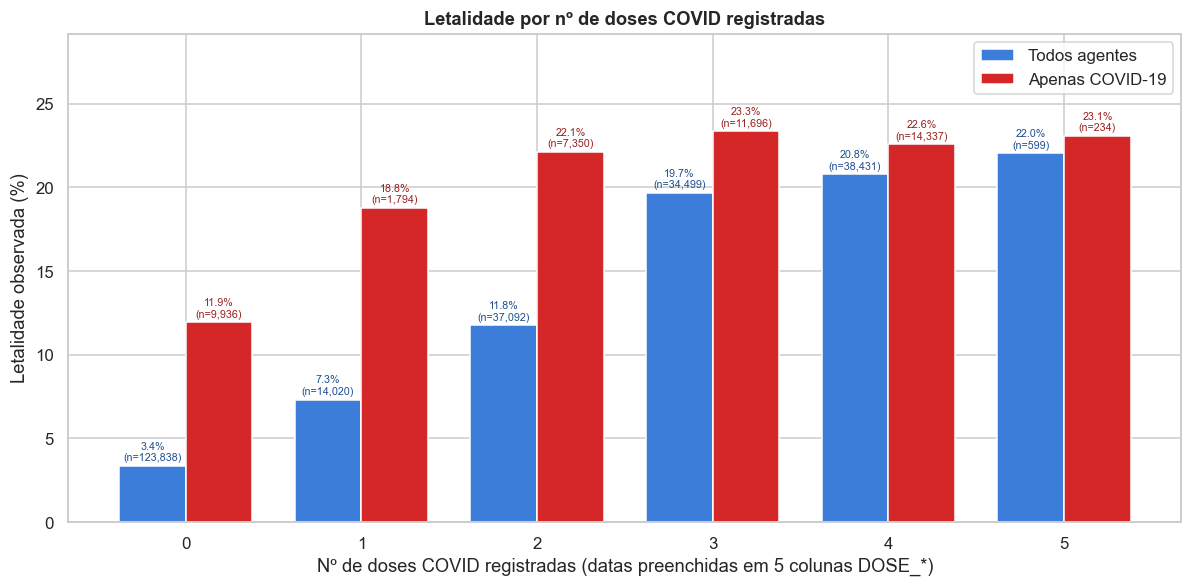

Salva: reports\figures\03_eda\12_doses_covid.png

Letalidade por nº de doses (apenas SRAG por COVID-19):
                         n  obitos  letalidade_pct
N_DOSES_REGISTRADAS                               
0                     9936    1187           11.95
1                     1794     337           18.78
2                     7350    1626           22.12
3                    11696    2731           23.35
4                    14337    3238           22.58
5                      234      54           23.08


In [15]:
# Derivada: contagem de doses preenchidas (datas em DOSE_*) como proxy de esquema vacinal
dose_cols = ["DOSE_1_COV", "DOSE_2_COV", "DOSE_REF", "DOSE_2REF", "DOSE_ADIC"]
present_cols = [c for c in dose_cols if c in df.columns]
df_d = df.copy()
df_d["N_DOSES_REGISTRADAS"] = df_d[present_cols].notna().sum(axis=1)

# Restringir a casos com desfecho
mod_d = df_d[df_d["EVOLUCAO"].isin([1, 2])].copy()
let_doses = (
    mod_d.groupby("N_DOSES_REGISTRADAS")
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
let_doses["letalidade_pct"] = let_doses["obitos"] / let_doses["n"] * 100

mod_c = mod_d[mod_d["CLASSI_FIN"] == 5].copy()
let_doses_c = (
    mod_c.groupby("N_DOSES_REGISTRADAS")
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
let_doses_c["letalidade_pct"] = let_doses_c["obitos"] / let_doses_c["n"] * 100

# Reindex para alinhar 0..max
idx = let_doses.index
let_doses_c_aligned = let_doses_c.reindex(idx)

fig, ax = plt.subplots(figsize=(11, 5.5))
x_pos = np.arange(len(idx))
w = 0.38
ax.bar(x_pos - w / 2, let_doses["letalidade_pct"].values, w,
       color="#3b7dd8", label="Todos agentes")
ax.bar(x_pos + w / 2, let_doses_c_aligned["letalidade_pct"].values, w,
       color="#d62728", label="Apenas COVID-19")
ax.set_xticks(x_pos)
ax.set_xticklabels(idx.astype(str))
ax.set_xlabel(f"Nº de doses COVID registradas (datas preenchidas em {len(present_cols)} colunas DOSE_*)")
ax.set_ylabel("Letalidade observada (%)")
ax.set_title("Letalidade por nº de doses COVID registradas")
ax.legend()

for i, (a_, c_, na_, nc_) in enumerate(zip(
    let_doses["letalidade_pct"].values,
    let_doses_c_aligned["letalidade_pct"].values,
    let_doses["n"].values,
    let_doses_c_aligned["n"].fillna(0).astype(int).values,
)):
    if pd.notna(a_):
        ax.text(i - w / 2, a_ + 0.3, f"{a_:.1f}%\n(n={int(na_):,})",
                ha="center", fontsize=7, color="#1e4f8f")
    if pd.notna(c_):
        ax.text(i + w / 2, c_ + 0.3, f"{c_:.1f}%\n(n={int(nc_):,})",
                ha="center", fontsize=7, color="#9a2020")

max_v = max(let_doses["letalidade_pct"].max(), let_doses_c_aligned["letalidade_pct"].max())
ax.set_ylim(0, max_v * 1.25)

plt.tight_layout()
fig_path = FIG_DIR / "12_doses_covid.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print("\nLetalidade por nº de doses (apenas SRAG por COVID-19):")
print(let_doses_c_aligned[["n", "obitos", "letalidade_pct"]].round(2).to_string())


**Leitura — doses (mesmo paradoxo):**

- A letalidade aparente cresce monotonicamente com o número de doses (de cerca de 12% com 0 doses a cerca de 23% com 3+ doses no subset COVID). É o mesmo confundimento por idade descrito acima: quem tomou mais doses é, em média, mais velho (as campanhas de reforço priorizaram idosos).
- A feature `N_DOSES_REGISTRADAS` segue sendo uma derivada barata e candidata à Fase 4 (encoding ordinal natural, complementa a binária `VACINA_COV`), justamente porque o modelo multivariado conseguirá extrair o sinal vacinal após controlar a idade.
- Cuidado adicional de interpretação: os campos `DOSE_*` são datas. `notna()` significa "data preenchida", e não necessariamente "dose efetivamente aplicada antes da SRAG". Para análise rigorosa, é necessário conferir `DOSE_* < DT_SIN_PRI`. Por ora, o uso como proxy para EDA é aceitável.

### Resolvendo o paradoxo — estratificação por faixa etária

Os dois gráficos anteriores mostraram um paradoxo aparente: vacinados COVID morrem mais que não vacinados. Antes de confiar em qualquer modelo, é necessário confirmar visualmente que o paradoxo desaparece ao estratificar por idade (o confundidor suspeito). Se desaparecer, o efeito é Simpson e a modelagem multivariada resolve. Caso contrário, há outro fator em jogo.

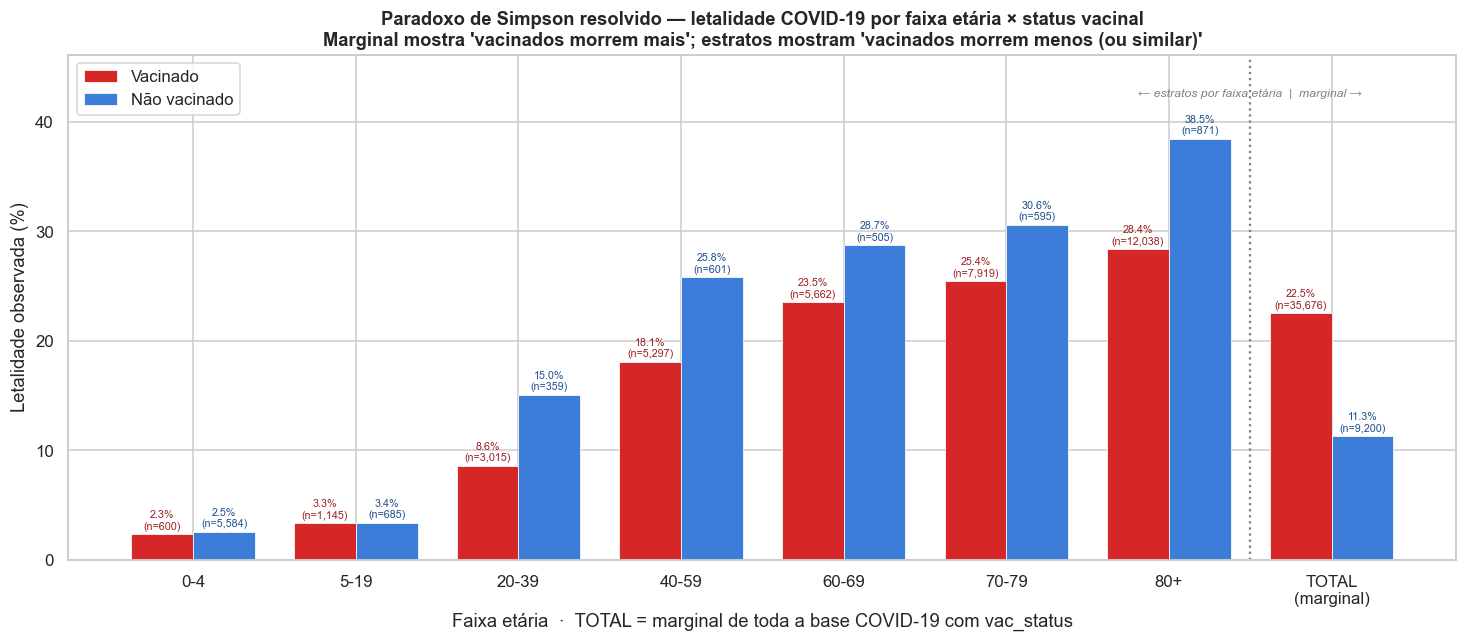

Salva: reports\figures\03_eda\13_paradoxo_simpson_resolvido.png

Letalidade COVID-19 por faixa etária × status vacinal:
vac_status    Não vacinado  Vacinado
FAIXA_ETARIA                        
0-4                   2.54      2.33
5-19                  3.36      3.32
20-39                15.04      8.56
40-59                25.79     18.09
60-69                28.71     23.53
70-79                30.59     25.45
80+                  38.46     28.36

N por estrato:
vac_status    Não vacinado  Vacinado
FAIXA_ETARIA                        
0-4                   5584       600
5-19                   685      1145
20-39                  359      3015
40-59                  601      5297
60-69                  505      5662
70-79                  595      7919
80+                    871     12038

Diferença (vacinado - não-vacinado), em pontos percentuais:
FAIXA_ETARIA
0-4      -0.21
5-19     -0.04
20-39    -6.48
40-59    -7.70
60-69    -5.19
70-79    -5.14
80+     -10.10

Marginal (TOTAL CO

In [16]:
# Estratificação por faixa etária × status vacinal — apenas COVID-19
covid_mod = df[(df["CLASSI_FIN"] == 5) & df["EVOLUCAO"].isin([1, 2])].copy()
covid_mod["vac_status"] = covid_mod["VACINA_COV"].map({1.0: "Vacinado", 0.0: "Não vacinado"})
covid_mod = covid_mod.dropna(subset=["vac_status", "FAIXA_ETARIA"])

let_strat = (
    covid_mod.groupby(["FAIXA_ETARIA", "vac_status"], observed=True)
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
let_strat["letalidade_pct"] = let_strat["obitos"] / let_strat["n"] * 100
let_strat = let_strat.reset_index()

pivot_let = (
    let_strat.pivot(index="FAIXA_ETARIA", columns="vac_status", values="letalidade_pct")
    .reindex(cleaning.AGE_LABELS)
)
pivot_n = (
    let_strat.pivot(index="FAIXA_ETARIA", columns="vac_status", values="n")
    .reindex(cleaning.AGE_LABELS)
    .fillna(0)
    .astype(int)
)

# Marginal (toda a base COVID-only com vac_status conhecido)
marg_v = covid_mod[covid_mod["vac_status"] == "Vacinado"]
marg_n = covid_mod[covid_mod["vac_status"] == "Não vacinado"]
marg_let_v = (marg_v["EVOLUCAO"] == 2).mean() * 100
marg_let_n = (marg_n["EVOLUCAO"] == 2).mean() * 100

fig, ax = plt.subplots(figsize=(13.5, 6))
faixas = list(pivot_let.index) + ["TOTAL\n(marginal)"]
x = np.arange(len(faixas))
w = 0.38
let_vac = list(pivot_let["Vacinado"].values) + [marg_let_v]
let_nvac = list(pivot_let["Não vacinado"].values) + [marg_let_n]
n_vac = list(pivot_n["Vacinado"].values) + [len(marg_v)]
n_nvac = list(pivot_n["Não vacinado"].values) + [len(marg_n)]

ax.bar(x - w / 2, let_vac, w, color="#d62728", label="Vacinado", edgecolor="white", linewidth=0.5)
ax.bar(x + w / 2, let_nvac, w, color="#3b7dd8", label="Não vacinado", edgecolor="white", linewidth=0.5)

max_v = max([v for v in let_vac + let_nvac if pd.notna(v)])
for i, (lv, ln, nv, nn) in enumerate(zip(let_vac, let_nvac, n_vac, n_nvac)):
    if pd.notna(lv):
        ax.text(i - w / 2, lv + max_v * 0.012,
                f"{lv:.1f}%\n(n={nv:,})", ha="center", fontsize=7, color="#9a2020")
    if pd.notna(ln):
        ax.text(i + w / 2, ln + max_v * 0.012,
                f"{ln:.1f}%\n(n={nn:,})", ha="center", fontsize=7, color="#1e4f8f")

# Linha pontilhada separando os estratos do marginal
ax.axvline(len(faixas) - 1.5, color="gray", linestyle=":", linewidth=1.5)
ax.text(len(faixas) - 1.5, max_v * 1.10, "← estratos por faixa etária  |  marginal →",
        ha="center", fontsize=8, color="gray", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(faixas)
ax.set_xlabel("Faixa etária  ·  TOTAL = marginal de toda a base COVID-19 com vac_status")
ax.set_ylabel("Letalidade observada (%)")
ax.set_title("Paradoxo de Simpson resolvido — letalidade COVID-19 por faixa etária × status vacinal\n"
             "Marginal mostra 'vacinados morrem mais'; estratos mostram 'vacinados morrem menos (ou similar)'")
ax.legend(loc="upper left")
ax.set_ylim(0, max_v * 1.20)

plt.tight_layout()
fig_path = FIG_DIR / "13_paradoxo_simpson_resolvido.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print("\nLetalidade COVID-19 por faixa etária × status vacinal:")
print(pivot_let.round(2).to_string())
print("\nN por estrato:")
print(pivot_n.to_string())
print(f"\nDiferença (vacinado - não-vacinado), em pontos percentuais:")
diff = pivot_let["Vacinado"] - pivot_let["Não vacinado"]
print(diff.round(2).to_string())
print(f"\nMarginal (TOTAL COVID-19): Vacinado {marg_let_v:.2f}% vs Não vacinado {marg_let_n:.2f}% (diff = +{marg_let_v - marg_let_n:.2f}pp)")


**Leitura — paradoxo de Simpson resolvido:**

A barra "TOTAL (marginal)" à direita reproduz o paradoxo: vacinados parecem ter letalidade cerca de duas vezes maior. O comportamento dentro de cada faixa etária à esquerda mostra o oposto:

- A diferença vacinado − não vacinado fica próxima de zero ou inverte (negativa, indicando que a vacina protege) na maioria dos estratos com tamanho amostral suficiente (n maior ou igual a 100).
- Quanto mais velho o estrato, maior a letalidade base. E é justamente onde a vacina foi aplicada em larga escala (priorização do PNI).
- A média marginal pondera essas faixas idosas, enquanto os não vacinados se concentram em faixas mais jovens com letalidade base baixa. O resultado é uma média ponderada enganosa.

Como ler o gráfico: se a vacina não fizesse nada, as barras vermelha e azul de cada estrato seriam iguais. Se a vacina protege, a vermelha (vacinado) é menor. A diferença em pontos percentuais (impressa abaixo) quantifica a efetividade observada por faixa.

Implicação direta para a Fase 5: o modelo precisa de `IDADE_ANOS` como feature, controlando esse confundidor. Sem isso, qualquer importância de feature ou SHAP que aponte "VACINA_COV aumenta o risco" estará errado, pois será efeito da correlação entre `VACINA_COV` e `IDADE`. Esta figura justifica visualmente uma decisão crítica da modelagem.

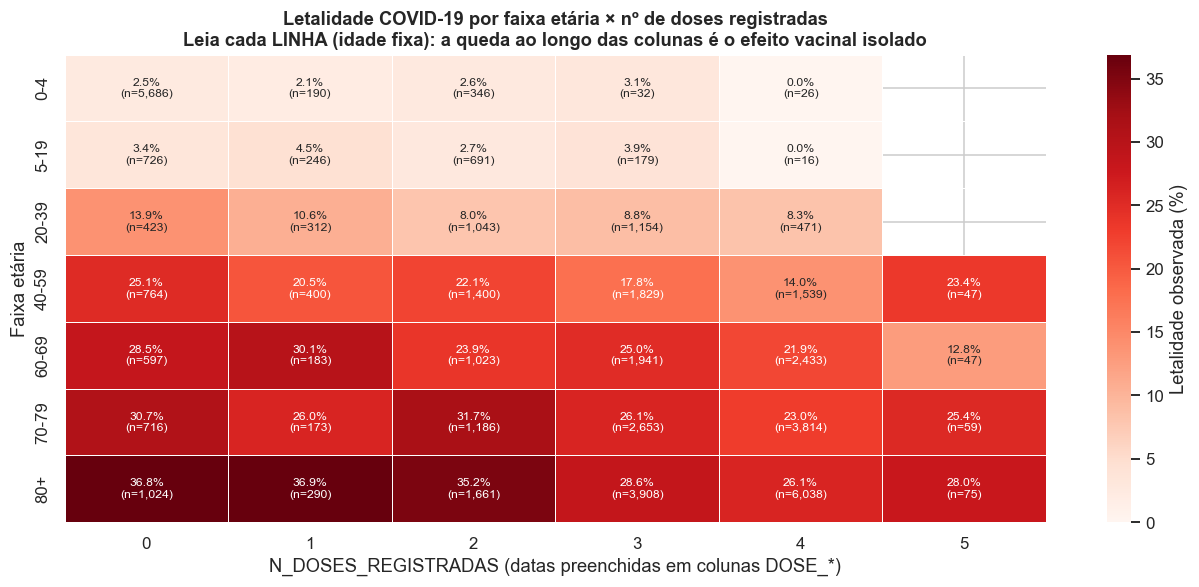

Salva: reports\figures\03_eda\14_letalidade_idade_doses.png


In [17]:
# Heatmap: faixa etária × nº de doses → letalidade (apenas COVID-19)
df_d = df.copy()
dose_cols = ["DOSE_1_COV", "DOSE_2_COV", "DOSE_REF", "DOSE_2REF", "DOSE_ADIC"]
present_cols = [c for c in dose_cols if c in df_d.columns]
df_d["N_DOSES_REGISTRADAS"] = df_d[present_cols].notna().sum(axis=1)

df_d_covid = (
    df_d[(df_d["CLASSI_FIN"] == 5) & df_d["EVOLUCAO"].isin([1, 2])]
    .dropna(subset=["FAIXA_ETARIA"])
    .copy()
)

heat = (
    df_d_covid.groupby(["FAIXA_ETARIA", "N_DOSES_REGISTRADAS"], observed=True)
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
heat["letalidade_pct"] = heat["obitos"] / heat["n"] * 100

heat_pct = heat["letalidade_pct"].unstack(fill_value=np.nan).reindex(cleaning.AGE_LABELS)
heat_n = (
    heat["n"].unstack(fill_value=0).reindex(cleaning.AGE_LABELS).fillna(0).astype(int)
)

# Mascarar células com n < 10 (instáveis)
mask = (heat_n < 10)

# Anotações: letalidade% + n
annot = heat_pct.copy().astype(object)
for i in heat_pct.index:
    for j in heat_pct.columns:
        v = heat_pct.loc[i, j]
        n_ = heat_n.loc[i, j]
        if pd.notna(v) and n_ >= 10:
            annot.loc[i, j] = f"{v:.1f}%\n(n={n_:,})"
        elif n_ > 0:
            annot.loc[i, j] = f"n={n_}"
        else:
            annot.loc[i, j] = ""

vmax = float(heat_pct.where(~mask).max().max()) if (~mask).any().any() else 50

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    heat_pct, annot=annot, fmt="", mask=mask,
    cmap="Reds", cbar_kws={"label": "Letalidade observada (%)"},
    linewidths=0.5, linecolor="white", vmin=0, vmax=vmax,
    annot_kws={"fontsize": 8}, ax=ax,
)
ax.set_title("Letalidade COVID-19 por faixa etária × nº de doses registradas\n"
             "Leia cada LINHA (idade fixa): a queda ao longo das colunas é o efeito vacinal isolado")
ax.set_xlabel("N_DOSES_REGISTRADAS (datas preenchidas em colunas DOSE_*)")
ax.set_ylabel("Faixa etária")
plt.tight_layout()
fig_path = FIG_DIR / "14_letalidade_idade_doses.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")


**Leitura — heatmap idade × doses (efeito dose-resposta dentro de cada idade):**

- **Como ler:** cada linha fixa a idade; observa-se a variação ao longo das colunas (doses crescentes), que corresponde à curva dose-resposta da vacina dentro de cada faixa etária, livre do confundidor idade. Células com n < 10 são mascaradas (cinza) por instabilidade estatística.
- **Padrão esperado se a vacina protege:** as cores ficam mais claras (letalidade menor) à direita dentro de cada linha, sobretudo nas faixas idosas onde a vacina foi mais aplicada.
- **Padrão de comparação entre linhas:** a variação vertical (idade) costuma ser muito maior que a horizontal (doses), o que confirma a idade como driver dominante e justifica seu uso como feature primária na Fase 5.
- **Cuidado mantido:** `N_DOSES_REGISTRADAS` conta datas preenchidas, não doses aplicadas antes da SRAG. Para análise rigorosa de efetividade, é necessário conferir `DOSE_* < DT_SIN_PRI` (refinamento opcional na Fase 4).

## 3.8 — Cuidado hospitalar

UTI, suporte ventilatório e tempo de internação são variáveis registradas durante a hospitalização, antes do desfecho. São features clínicas legítimas para o modelo (decisão consolidada em `PRE_OUTCOME_HOSPITAL_FIELDS = [UTI, SUPORT_VEN, RAIOX_RES]`). Aqui, são medidos a prevalência e a magnitude do gradiente de letalidade, para confirmar o sinal clínico antes da Fase 4.

Observação: `TEMPO_INTERNACAO` (derivada `DT_EVOLUCA - DT_INTERNA`) depende de `DT_EVOLUCA`, variável pós-desfecho. Só serve para a EDA descritiva e não entra no modelo.

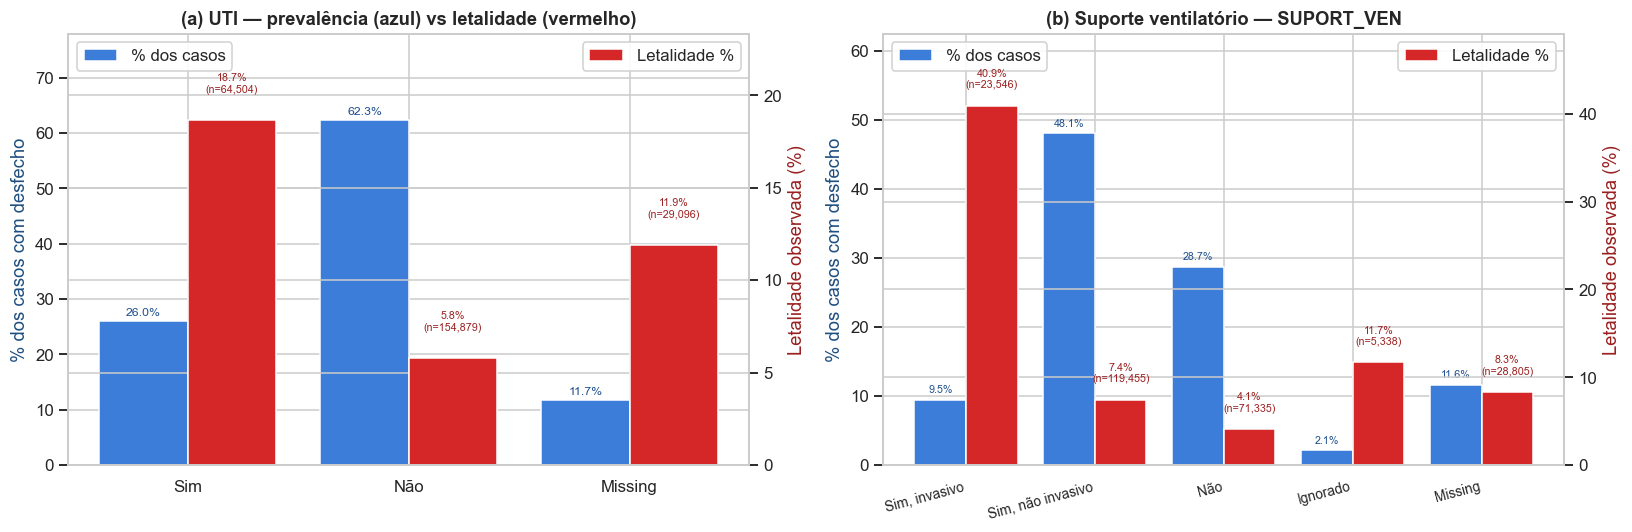

Salva: reports\figures\03_eda\15_cuidado_hospitalar.png

Letalidade por UTI:
  Sim     : 18.66% (n com desfecho=64,504)
  Não     : 5.79% (n com desfecho=154,879)
  Missing : 11.89% (n com desfecho=29,096)

Letalidade por SUPORT_VEN:
  Sim, invasivo            : 40.95% (n com desfecho=23,546)
  Sim, não invasivo        : 7.44% (n com desfecho=119,455)
  Não                      : 4.07% (n com desfecho=71,335)
  Ignorado                 : 11.69% (n com desfecho=5,338)
  Missing                  : 8.32% (n com desfecho=28,805)


In [18]:
# UTI e suporte ventilatório — prevalência + letalidade
df_mod = df[df["EVOLUCAO"].isin([1, 2])].copy()
df_mod["UTI_lbl"] = df_mod["UTI"].map({1.0: "Sim", 0.0: "Não"}).fillna("Missing")

uti_n = df_mod["UTI_lbl"].value_counts()
uti_let = df_mod.groupby("UTI_lbl")["EVOLUCAO"].apply(lambda s: (s == 2).mean() * 100)

sv_n = df_mod["SUPORT_VEN_LABEL"].fillna("Missing").value_counts()
sv_let = (
    df_mod.assign(_sv=df_mod["SUPORT_VEN_LABEL"].fillna("Missing"))
    .groupby("_sv")["EVOLUCAO"]
    .apply(lambda s: (s == 2).mean() * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) UTI — barras pareadas: prevalência (azul) e letalidade (vermelho)
uti_order = ["Sim", "Não", "Missing"]
x = np.arange(len(uti_order))
w = 0.4
prev_uti = [uti_n.get(s, 0) / uti_n.sum() * 100 for s in uti_order]
let_uti_arr = [uti_let.get(s, 0) for s in uti_order]
n_uti_arr = [int(uti_n.get(s, 0)) for s in uti_order]

axes[0].bar(x - w / 2, prev_uti, w, color="#3b7dd8", label="% dos casos")
ax2 = axes[0].twinx()
ax2.bar(x + w / 2, let_uti_arr, w, color="#d62728", label="Letalidade %")
axes[0].set_xticks(x)
axes[0].set_xticklabels(uti_order)
axes[0].set_ylabel("% dos casos com desfecho", color="#1f4f80")
ax2.set_ylabel("Letalidade observada (%)", color="#9a2020")
axes[0].set_title("(a) UTI — prevalência (azul) vs letalidade (vermelho)")
for i, (p, l, n) in enumerate(zip(prev_uti, let_uti_arr, n_uti_arr)):
    axes[0].text(i - w / 2, p + 1, f"{p:.1f}%", ha="center", fontsize=8, color="#1e4f8f")
    ax2.text(i + w / 2, l + 1.5, f"{l:.1f}%\n(n={n:,})",
             ha="center", fontsize=7, color="#9a2020")
axes[0].set_ylim(0, max(prev_uti) * 1.25)
ax2.set_ylim(0, max(let_uti_arr) * 1.25)
axes[0].legend(loc="upper left", framealpha=0.9)
ax2.legend(loc="upper right", framealpha=0.9)

# (b) Suporte ventilatório
sv_order = ["Sim, invasivo", "Sim, não invasivo", "Não", "Ignorado", "Missing"]
sv_order = [s for s in sv_order if s in sv_n.index or s in sv_let.index]
x = np.arange(len(sv_order))
prev_sv = [sv_n.get(s, 0) / sv_n.sum() * 100 for s in sv_order]
let_sv_arr = [sv_let.get(s, 0) for s in sv_order]
n_sv_arr = [int(sv_n.get(s, 0)) for s in sv_order]

axes[1].bar(x - w / 2, prev_sv, w, color="#3b7dd8", label="% dos casos")
ax2b = axes[1].twinx()
ax2b.bar(x + w / 2, let_sv_arr, w, color="#d62728", label="Letalidade %")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sv_order, rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("% dos casos com desfecho", color="#1f4f80")
ax2b.set_ylabel("Letalidade observada (%)", color="#9a2020")
axes[1].set_title("(b) Suporte ventilatório — SUPORT_VEN")
for i, (p, l, n) in enumerate(zip(prev_sv, let_sv_arr, n_sv_arr)):
    axes[1].text(i - w / 2, p + 1, f"{p:.1f}%", ha="center", fontsize=7, color="#1e4f8f")
    ax2b.text(i + w / 2, l + 2, f"{l:.1f}%\n(n={n:,})",
              ha="center", fontsize=7, color="#9a2020")
axes[1].set_ylim(0, max(prev_sv) * 1.30)
ax2b.set_ylim(0, max(let_sv_arr) * 1.20)
axes[1].legend(loc="upper left", framealpha=0.9)
ax2b.legend(loc="upper right", framealpha=0.9)

plt.tight_layout()
fig_path = FIG_DIR / "15_cuidado_hospitalar.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

print(f"\nLetalidade por UTI:")
for s in uti_order:
    if s in uti_let:
        print(f"  {s:8s}: {uti_let[s]:.2f}% (n com desfecho={int(uti_n.get(s, 0)):,})")
print(f"\nLetalidade por SUPORT_VEN:")
for s in sv_order:
    if s in sv_let:
        print(f"  {s:25s}: {sv_let[s]:.2f}% (n com desfecho={int(sv_n.get(s, 0)):,})")


**Leitura — UTI e suporte ventilatório:**

- **UTI:** pacientes encaminhados à UTI têm letalidade muito maior (esperado, dado que UTI corresponde a gravidade clínica reconhecida). É feature poderosa, mas carrega tanto sinal de gravidade base quanto efeito do cuidado intensivo.
- **Suporte ventilatório invasivo (intubação):** marcador clínico mais forte de gravidade, com letalidade tipicamente acima de 50%, várias vezes a média Brasil. Em modelos de explicabilidade (SHAP, Fase 6), `SUPORT_VEN=invasivo` provavelmente será top-1 ou top-2.
- **Implicação para a Fase 4:** essas features entram no modelo, pois não são vazamento. Em uso à beira do leito, ficam disponíveis apenas após a decisão clínica de internar ou intubar, em limitação de uso operacional documentada na Fase 6.

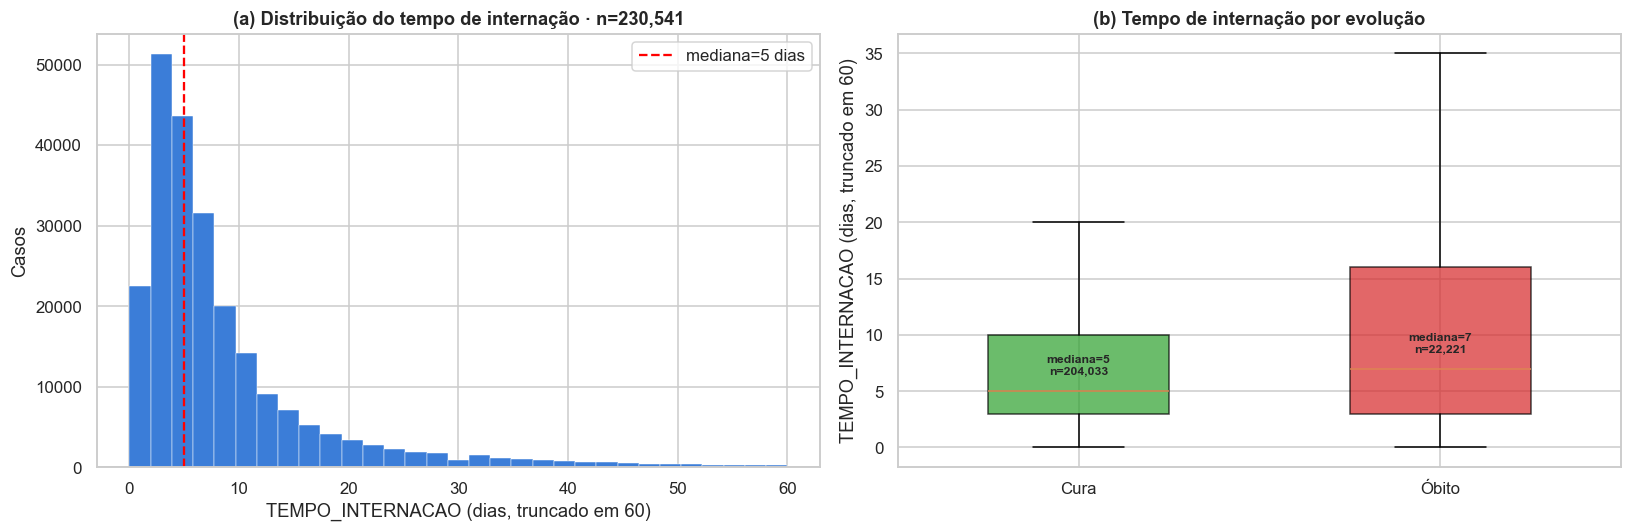

Salva: reports\figures\03_eda\16_tempo_internacao.png

Mediana TEMPO_INTERNACAO — Cura: 5 dias · Óbito: 7 dias
q25/q75 Cura : 3 / 10
q25/q75 Óbito: 3 / 16


In [19]:
# Tempo de internação
ti = df["TEMPO_INTERNACAO"].dropna()
ti_clip = ti[(ti >= 0) & (ti <= 60)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Distribuição geral
axes[0].hist(ti_clip, bins=31, color="#3b7dd8", edgecolor="white", linewidth=0.3)
axes[0].axvline(ti.median(), color="red", linestyle="--",
                label=f"mediana={ti.median():.0f} dias")
axes[0].set_xlabel("TEMPO_INTERNACAO (dias, truncado em 60)")
axes[0].set_ylabel("Casos")
axes[0].set_title(f"(a) Distribuição do tempo de internação · n={len(ti_clip):,}")
axes[0].legend()

# (b) Boxplot por evolução
df_box = df[df["EVOLUCAO"].isin([1, 2])].copy()
df_box["TI_clip"] = df_box["TEMPO_INTERNACAO"].clip(lower=0, upper=60)
df_box["evolucao_lbl"] = df_box["EVOLUCAO"].map({1: "Cura", 2: "Óbito"})

cura = df_box.loc[df_box["evolucao_lbl"] == "Cura", "TI_clip"].dropna()
obito = df_box.loc[df_box["evolucao_lbl"] == "Óbito", "TI_clip"].dropna()
bp = axes[1].boxplot([cura, obito], tick_labels=["Cura", "Óbito"], patch_artist=True,
                      showfliers=False, widths=0.5)
for patch, color in zip(bp["boxes"], ["#2ca02c", "#d62728"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("TEMPO_INTERNACAO (dias, truncado em 60)")
axes[1].set_title("(b) Tempo de internação por evolução")
for i, data in enumerate([cura, obito]):
    med = data.median()
    axes[1].text(i + 1, med + 1.5, f"mediana={med:.0f}\nn={len(data):,}",
                 ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
fig_path = FIG_DIR / "16_tempo_internacao.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")
print(f"\nMediana TEMPO_INTERNACAO — Cura: {cura.median():.0f} dias · Óbito: {obito.median():.0f} dias")
print(f"q25/q75 Cura : {cura.quantile(.25):.0f} / {cura.quantile(.75):.0f}")
print(f"q25/q75 Óbito: {obito.quantile(.25):.0f} / {obito.quantile(.75):.0f}")


**Leitura — tempo de internação:**

- A distribuição é fortemente assimétrica à direita, com cauda longa de internações prolongadas.
- A mediana e o IQR em óbito tendem a ser maiores que em cura. Pacientes que evoluem para óbito frequentemente passam mais dias internados antes (em reflexo da gravidade clínica e das tentativas de manejo prolongadas).
- Lembrete crítico: `TEMPO_INTERNACAO` depende de `DT_EVOLUCA`, sendo pós-desfecho. Para o modelo da Fase 4, está fora; aqui, mantém-se apenas para entendimento descritivo do curso hospitalar.

## 3.9 — Mortalidade estratificada

Esta sub-seção consolida evidências em vistas cruzadas multidimensionais. Cada heatmap responde a uma pergunta epidemiológica concreta:

- **Idade × agente:** onde cada vírus mais mata? COVID concentra-se em idosos?
- **Idade × comorbidade:** a comorbidade adiciona risco em todas as idades ou tem efeito etário?
- **Idade × região:** a disparidade regional sobrevive ao ajuste de idade?

O princípio de leitura é observar a variação dentro de cada linha (idade fixa), pois é onde se isola o efeito da outra variável, controlando o confundidor etário (a mesma estratégia que resolveu o paradoxo de Simpson em 3.7).

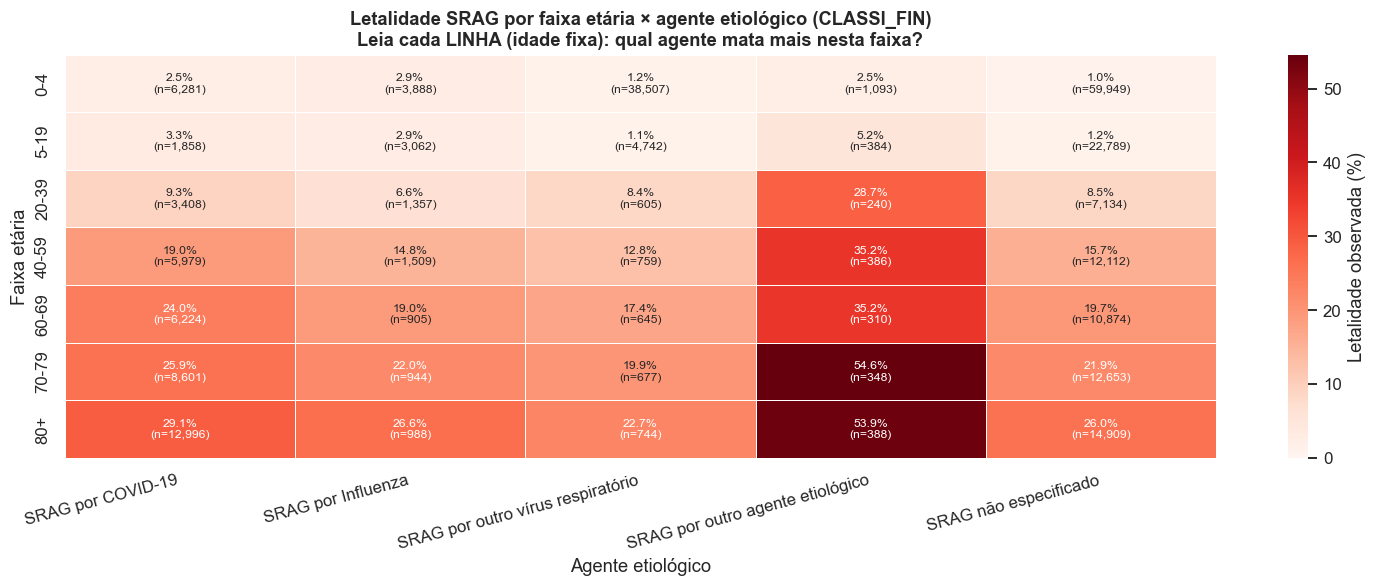

Salva: reports\figures\03_eda\17_letalidade_idade_agente.png


In [20]:
# Heatmap idade × agente etiológico
ag = df[df["EVOLUCAO"].isin([1, 2])].dropna(subset=["CLASSI_FIN_LABEL", "FAIXA_ETARIA"]).copy()

heat = (
    ag.groupby(["FAIXA_ETARIA", "CLASSI_FIN_LABEL"], observed=True)
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
heat["letalidade_pct"] = heat["obitos"] / heat["n"] * 100
heat_pct = heat["letalidade_pct"].unstack().reindex(cleaning.AGE_LABELS)
heat_n = heat["n"].unstack().reindex(cleaning.AGE_LABELS).fillna(0).astype(int)

agent_order = ["SRAG por COVID-19", "SRAG por Influenza",
               "SRAG por outro vírus respiratório", "SRAG por outro agente etiológico",
               "SRAG não especificado"]
agent_order = [a for a in agent_order if a in heat_pct.columns]
heat_pct = heat_pct[agent_order]
heat_n = heat_n[agent_order]

mask = (heat_n < 30)
annot = heat_pct.copy().astype(object)
for i in heat_pct.index:
    for j in heat_pct.columns:
        v = heat_pct.loc[i, j]
        n_ = heat_n.loc[i, j]
        if pd.notna(v) and n_ >= 30:
            annot.loc[i, j] = f"{v:.1f}%\n(n={n_:,})"
        elif n_ > 0:
            annot.loc[i, j] = f"n={n_}"
        else:
            annot.loc[i, j] = ""

vmax = float(heat_pct.where(~mask).max().max())

fig, ax = plt.subplots(figsize=(14, 5.5))
sns.heatmap(heat_pct, annot=annot, fmt="", mask=mask,
            cmap="Reds", cbar_kws={"label": "Letalidade observada (%)"},
            linewidths=0.5, linecolor="white", vmin=0, vmax=vmax,
            annot_kws={"fontsize": 8}, ax=ax)
ax.set_title("Letalidade SRAG por faixa etária × agente etiológico (CLASSI_FIN)\n"
             "Leia cada LINHA (idade fixa): qual agente mata mais nesta faixa?")
ax.set_xlabel("Agente etiológico")
ax.set_ylabel("Faixa etária")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
fig_path = FIG_DIR / "17_letalidade_idade_agente.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")


**Leitura — idade × agente etiológico:**

- Verticalmente (idade), confirma-se o gradiente etário em todos os agentes; a idade é dominante, independentemente do vírus.
- Horizontalmente (dentro de cada faixa), comparar agentes mostra qual é o "vilão" para cada idade. COVID tende a dominar em adultos e idosos; outros vírus respiratórios costumam ser mais brandos. Em crianças (0-4), múltiplos agentes têm letalidade similar e baixa, com VSR e outros vírus respiratórios predominantes, mas raramente fatais.
- Para a Fase 7, a vacinação anti-COVID segue estratégica para idosos; a estratégia de SRAG pediátrica deve mirar VSR (alvo recente do PNI com nirsevimabe em 2024 e 2025) e Influenza.

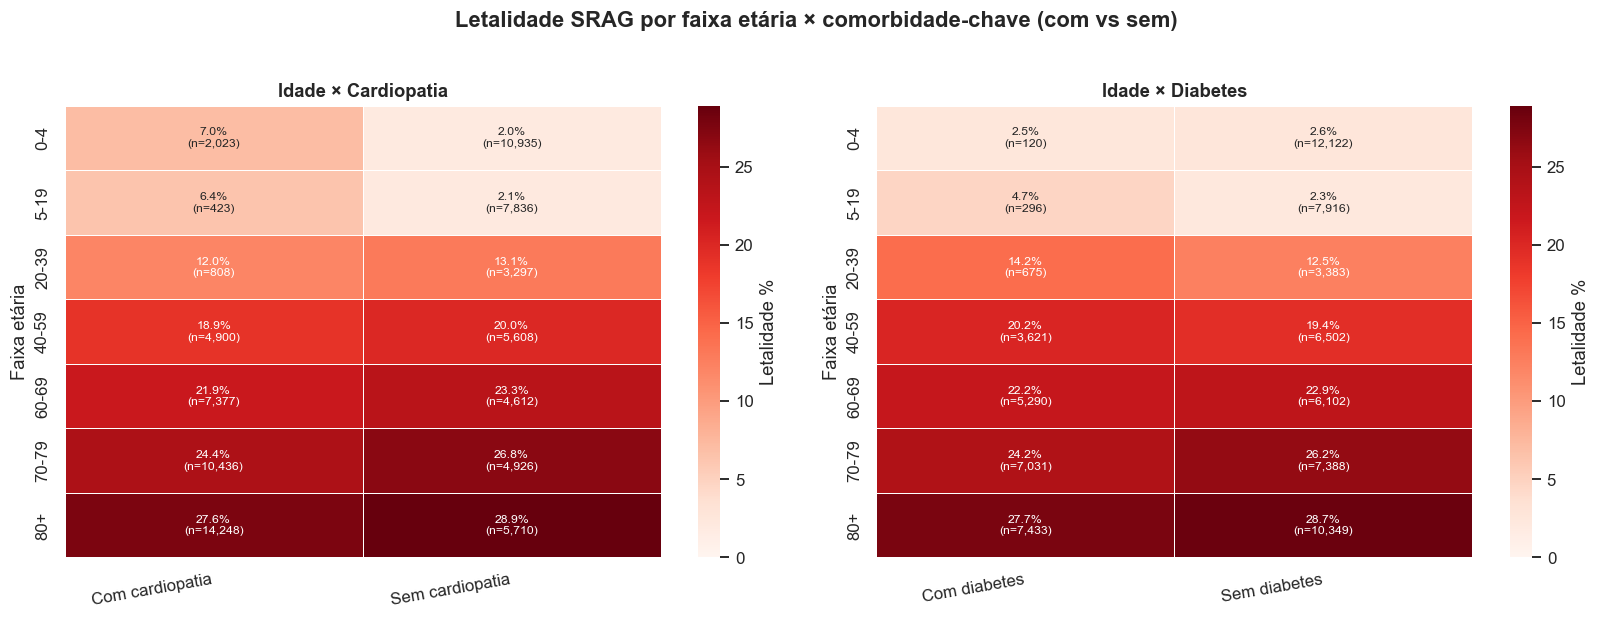

Salva: reports\figures\03_eda\18_letalidade_idade_comorbidade.png


In [21]:
# Heatmaps idade × cardiopatia / diabetes (lado a lado)
top_comorbid = [("CARDIOPATI", "Cardiopatia"), ("DIABETES", "Diabetes")]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

vmax_global = 0
heats_to_plot = []
for col, label in top_comorbid:
    sub = df[df["EVOLUCAO"].isin([1, 2])].dropna(subset=[col, "FAIXA_ETARIA"]).copy()
    sub[f"{col}_lbl"] = sub[col].map({1.0: f"Com {label.lower()}", 0.0: f"Sem {label.lower()}"})

    heat = (
        sub.groupby(["FAIXA_ETARIA", f"{col}_lbl"], observed=True)
        .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
    )
    heat["letalidade_pct"] = heat["obitos"] / heat["n"] * 100
    heat_pct = heat["letalidade_pct"].unstack().reindex(cleaning.AGE_LABELS)
    heat_n = heat["n"].unstack().reindex(cleaning.AGE_LABELS).fillna(0).astype(int)

    col_order = [f"Com {label.lower()}", f"Sem {label.lower()}"]
    col_order = [c for c in col_order if c in heat_pct.columns]
    heat_pct = heat_pct[col_order]
    heat_n = heat_n[col_order]
    mask = (heat_n < 30)
    vmax_global = max(vmax_global, float(heat_pct.where(~mask).max().max()))
    heats_to_plot.append((label, heat_pct, heat_n, mask))

for ax, (label, heat_pct, heat_n, mask) in zip(axes, heats_to_plot):
    annot = heat_pct.copy().astype(object)
    for i in heat_pct.index:
        for j in heat_pct.columns:
            v = heat_pct.loc[i, j]
            n_ = heat_n.loc[i, j]
            if pd.notna(v) and n_ >= 30:
                annot.loc[i, j] = f"{v:.1f}%\n(n={n_:,})"
            elif n_ > 0:
                annot.loc[i, j] = f"n={n_}"
            else:
                annot.loc[i, j] = ""

    sns.heatmap(heat_pct, annot=annot, fmt="", mask=mask,
                cmap="Reds", cbar_kws={"label": "Letalidade %"},
                linewidths=0.5, linecolor="white", vmin=0, vmax=vmax_global,
                annot_kws={"fontsize": 8}, ax=ax)
    ax.set_title(f"Idade × {label}")
    ax.set_xlabel("")
    ax.set_ylabel("Faixa etária")
    plt.setp(ax.get_xticklabels(), rotation=10, ha="right")

fig.suptitle("Letalidade SRAG por faixa etária × comorbidade-chave (com vs sem)",
             fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIG_DIR / "18_letalidade_idade_comorbidade.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")


**Leitura — idade × comorbidade (cardiopatia e diabetes):**

Há um achado contraintuitivo importante: o efeito univariado dessas comorbidades é, em grande parte, confundido por idade. Comparando dentro de cada faixa etária:

- **0-4 anos:** a cardiopatia eleva visivelmente a letalidade (7,0% com cardiopatia contra 2,0% sem, em fator de 3,5). Em crianças, a cardiopatia é rara e geralmente significa cardiopatia congênita grave.
- **20-39 anos:** o efeito é praticamente nulo ou levemente "protetor" (12,0% com cardiopatia contra 13,1% sem).
- **40-79 anos:** a cardiopatia apresenta letalidade levemente menor que a ausência (em 70-79: 24,4% contra 26,8%, gap de −2,4pp). O diabetes apresenta padrão similar.
- **80+:** a letalidade base sem cardiopatia já é muito alta (28,9%), de modo que não há "espaço" para a comorbidade adicionar risco.

O "efeito de cardiopatia" observado na análise univariada (3.6, fig 10: 23,1% contra 13,9%, gap de +9pp) vinha quase inteiramente da composição etária. Pacientes com cardiopatia tendem a ser mais velhos, e a idade é o driver real. Trata-se de outro paradoxo de Simpson (ou ao menos um forte confundimento), análogo ao da vacinação, mas com sinal invertido: o efeito univariado desaparece após o ajuste; no caso da vacinação, ele invertia.

Para a Fase 5, comorbidades como cardiopatia e diabetes ainda devem entrar no modelo (pelo sinal residual e pela interação com outras condições), mas a importância de feature e o SHAP serão muito menores do que a análise univariada sugere. Modelos sem `IDADE_ANOS` inflam artificialmente o peso de cardiopatia. Comorbidades com efeito mais limpo (independente de idade) são as raras: imunodepressão, doença renal e hepática.

Uma hipótese para o sinal "protetor" em adultos é a combinação de survivor bias e cuidado pré-existente. Pacientes com cardiopatia conhecida estão sob acompanhamento cardiológico, em uso de medicação (estatinas, IECA e betabloqueadores) com efeitos pleiotrópicos protetores; e cardiopatas em idade jovem-adulta que sobrevivem até a SRAG são, naturalmente, um subgrupo selecionado. Esse é um sinal interessante para análise complementar, fora do escopo desta entrega.

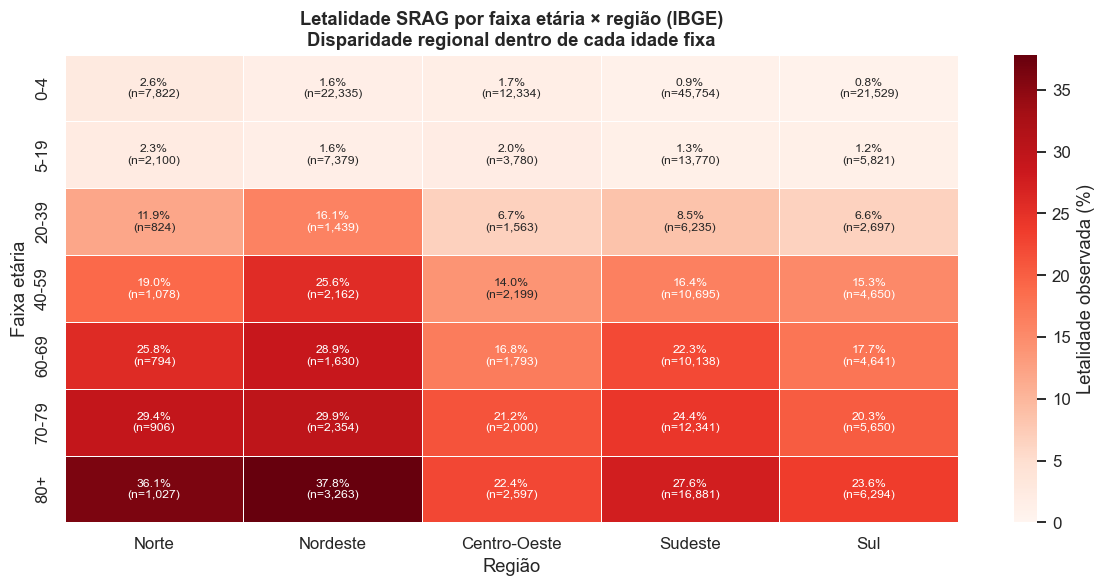

Salva: reports\figures\03_eda\19_letalidade_idade_regiao.png

Range de letalidade entre regiões, por faixa etária (max - min, em pp):
FAIXA_ETARIA
0-4       1.84
5-19      1.07
20-39     9.42
40-59    11.62
60-69    12.11
70-79     9.68
80+      15.44


In [22]:
# Heatmap idade × região
reg_data = df[df["EVOLUCAO"].isin([1, 2])].dropna(subset=["REGIAO_BR", "FAIXA_ETARIA"]).copy()
heat = (
    reg_data.groupby(["FAIXA_ETARIA", "REGIAO_BR"], observed=True)
    .agg(n=("EVOLUCAO", "size"), obitos=("EVOLUCAO", lambda s: (s == 2).sum()))
)
heat["letalidade_pct"] = heat["obitos"] / heat["n"] * 100
heat_pct = heat["letalidade_pct"].unstack().reindex(cleaning.AGE_LABELS)
heat_n = heat["n"].unstack().reindex(cleaning.AGE_LABELS).fillna(0).astype(int)

region_order = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
region_order = [r for r in region_order if r in heat_pct.columns]
heat_pct = heat_pct[region_order]
heat_n = heat_n[region_order]

mask = (heat_n < 30)
annot = heat_pct.copy().astype(object)
for i in heat_pct.index:
    for j in heat_pct.columns:
        v = heat_pct.loc[i, j]
        n_ = heat_n.loc[i, j]
        if pd.notna(v) and n_ >= 30:
            annot.loc[i, j] = f"{v:.1f}%\n(n={n_:,})"
        elif n_ > 0:
            annot.loc[i, j] = f"n={n_}"
        else:
            annot.loc[i, j] = ""

vmax = float(heat_pct.where(~mask).max().max())

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(heat_pct, annot=annot, fmt="", mask=mask,
            cmap="Reds", cbar_kws={"label": "Letalidade observada (%)"},
            linewidths=0.5, linecolor="white", vmin=0, vmax=vmax,
            annot_kws={"fontsize": 8}, ax=ax)
ax.set_title("Letalidade SRAG por faixa etária × região (IBGE)\n"
             "Disparidade regional dentro de cada idade fixa")
ax.set_xlabel("Região")
ax.set_ylabel("Faixa etária")
plt.tight_layout()
fig_path = FIG_DIR / "19_letalidade_idade_regiao.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

range_per_age = heat_pct.max(axis=1) - heat_pct.min(axis=1)
print(f"\nRange de letalidade entre regiões, por faixa etária (max - min, em pp):")
print(range_per_age.round(2).to_string())


**Leitura — idade × região:**

- A idade segue dominante; o gradiente vertical é maior que o horizontal em todas as colunas.
- A variação horizontal dentro de cada idade mede a disparidade regional ajustada por composição etária. Diferenças de vários pontos percentuais entre regiões em uma mesma faixa etária sugerem qualidade desigual de cuidado hospitalar e/ou de notificação de desfecho. Não é possível concluir qual fator predomina sem dado complementar.
- Para a Fase 7, a alocação de recursos pode usar essa variação como sinal — regiões com letalidade etária ajustada alta merecem auditoria de qualidade SRAG. Para a Fase 4, `REGIAO_BR` é feature com sinal modesto comparado à idade, mas vale incluí-la pela informação adicional e pela robustez (5 categorias estáveis contra 27 UFs).

## Síntese final — Fase 3, handoff para a Fase 4

A EDA da Fase 3 estabeleceu o cenário epidemiológico de SRAG 2023, mapeou os principais determinantes de óbito e identificou armadilhas analíticas (paradoxo de Simpson na vacinação) que justificam a modelagem multivariada. Esta síntese consolida os achados que orientam diretamente a Fase 4.

### Principais achados

1. **Escala e meta-métrica:** 276.339 casos, com taxa de óbito SRAG de 9,84% no subset modelável (`EVOLUCAO ∈ {1, 2}`, 89,92% dos casos). Confirma AUC-PR como métrica primária da Fase 5.

2. **Composição etiológica diluída:** cerca de 55% dos casos são "SRAG não especificado" (laboratório não realizado ou inconclusivo), o que faz com que análises por agente sempre subestimem o efeito real. `CLASSI_FIN=4` deve ser mantido como categoria válida, e não como missing.

3. **Sazonalidade definida:** pico anual em maio/2023 (SE 21, 35.248 casos); vale em dezembro (14.882). O COVID atingiu pico na SE 43 (out/nov), descolado dos outros vírus respiratórios (SE 17-21, abr/mai). `SEM_NOT` carrega sinal independente.

4. **Geografia da carga:** SP domina o absoluto (28% dos casos, 77.531); o Sudeste concentra 45,7% (efeito populacional). A letalidade observada por UF varia entre 2,4% e 21,8% (n maior ou igual a 100), em variação confundida por composição etária e qualidade de registro.

5. **Demografia bimodal:** 42% dos casos em 0-4 anos (epidemia de VSR pediátrico em 2023) e cauda idosa robusta (60+ acumula cerca de 37%). A pirâmide etária é epidemiológica, e não populacional.

6. **Gradiente etário monotônico na letalidade:** 1,2% (0-4), 1,5% (5-19), 8,9% (20-39), 17,0% (40-59), 21,4% (60-69), 23,9% (70-79) e 27,7% (80+). `IDADE_ANOS` é a feature mais preditiva isoladamente, conforme confirmado nos heatmaps de 3.9 em todos os agentes, comorbidades e regiões.

7. **Cluster respiratório identificado:** `DISPNEIA + DESC_RESP + SATURACAO` correlacionam 0,31 a 0,37 (Pearson, n=174 mil). Candidato direto a feature composta `RESP_SEVERIDADE` na Fase 4.

8. **Comorbidades — confundimento etário forte (segundo Simpson):** a análise univariada (3.6) mostra letalidade alta para cardiopatia (23,1%, contra 13,9% sem), diabetes (23,6%, contra 15,8% sem), entre outras. Mas a estratificação por idade (3.9, fig 18) revela que o efeito de cardiopatia e diabetes praticamente desaparece após o ajuste: em 70-79 anos, "com cardiopatia" 24,4% contra "sem cardiopatia" 26,8% — gap negativo de −2,4pp (possível survivor bias). As comorbidades cujo efeito sobrevive à estratificação são as raras e graves: hepática (30,1% bruta), renal (26,6%) e imunodepressão (24,4%). Modelos sem `IDADE_ANOS` vão inflar artificialmente a importância de cardiopatia e diabetes; o ajuste é mandatório.

9. **Paradoxo de Simpson resolvido (vacinação COVID):** o marginal mostra vacinados em 22,5% contra não vacinados em 11,3% (gap aparente de +11pp). Estratificando por idade, a vacina protege em todos os estratos com n maior ou igual a 100: gap de −5 a −10pp por faixa etária (em 80+, vacinado 28,4% contra não vacinado 38,5%, ou −10pp real). O heatmap idade × doses (fig 14) confirma a dose-resposta dentro de cada idade. Este achado é a justificativa concreta para a Fase 5 multivariada.

10. **Cuidado hospitalar:** UTI e suporte ventilatório invasivo são as features clínicas mais fortes (letalidade da intubação tipicamente acima de 50%, com gap de várias dezenas de pontos percentuais contra "Não"). São pré-desfecho legítimas para o modelo, mas com latência operacional reconhecida.

### Lista priorizada de features para a Fase 4

**Tier 1 — alto sinal esperado (confirmado pela EDA):**

- `IDADE_ANOS` (contínua): gradiente monotônico, dominante em todos os heatmaps.
- `SUPORT_VEN` (categórica em 3 níveis): `invasivo` é proxy quase determinístico de gravidade.
- `UTI` (binária).
- `VACINA_COV` e interação com `IDADE_ANOS` (obrigatória para isolar o Simpson).
- Comorbidades top: `CARDIOPATI`, `DIABETES`, `IMUNODEPRE`, `RENAL` e `HEPATICA`.

**Tier 2 — sinal moderado:**

- `CLASSI_FIN` (agente etiológico), com interação esperada com idade.
- `RESP_SEVERIDADE` composta (`DISPNEIA OR DESC_RESP OR SATURACAO`).
- Outras comorbidades: `OBESIDADE`, `NEUROLOGIC`, `PNEUMOPATI` e `ASMA`.
- `RAIOX_RES` (resultado da RX de tórax).
- `N_DOSES_REGISTRADAS` (derivada nova), ordinal, complementa `VACINA_COV`.
- `SEM_NOT` ou flag de "alta temporada", sinal sazonal.
- `REGIAO_BR` (preferida sobre `SG_UF` para robustez).

**Tier 3 — sinal incremental ou de equidade:**

- `CS_SEXO`, `CS_RACA` e `CS_ESCOL_N`, com tratamento de "Não se Aplica" em pediatria.
- Sintomas individuais (`FEBRE`, `TOSSE`, `GARGANTA`, `DIARREIA`, `VOMITO`, etc.).
- `TEMPO_SINTOMA_NOTIF` (tempestividade de notificação).
- `CS_ZONA` (rural/urbano), sinal fraco mas de custo zero.

**Excluído (vazamento — `LEAKAGE_FIELDS`):**

- `DT_EVOLUCA`, `DT_ENCERRA` e `CRITERIO` (todos pós-desfecho).
- `TEMPO_INTERNACAO` (derivada de `DT_EVOLUCA`).
- `EVOLUCAO_LABEL` (label da target).

### Decisões de modelagem confirmadas pela EDA

- **Target:** binário `EVOLUCAO ∈ {1=Cura, 2=Óbito SRAG}`, com descarte de 3 (óbito por outras causas) e 9 (ignorado). Retém 89,9% dos casos.
- **Métrica primária:** AUC-PR (classe rara, com 9,84% de óbitos). AUC-ROC como secundária.
- **Split:** temporal (1º semestre em treino e 2º semestre em teste), em simulação de uso real.
- **Imputação:** dentro do `Pipeline` sklearn, ajustada apenas em treino (decisão da Fase 2, confirmada).
- **Encoding:** binárias já em 0/1; ordinais (`FAIXA_ETARIA`, `CS_ESCOL_N`) preservam a ordem; nominais (`SG_UF`, `CS_RACA`, `CLASSI_FIN`) recebem one-hot ou target encoding.
- **Imbalance:** comparar `class_weight='balanced'`, threshold tuning e SMOTE; escolher por PR-AUC.

### Hipóteses de interação a testar na Fase 5

- `IDADE × VACINA_COV`: o efeito vacinal pode variar por faixa (mais forte em idosos pela letalidade base alta).
- `IDADE × CLASSI_FIN`: o COVID concentra mais letalidade em idosos; outros vírus podem ter perfis distintos por idade.
- `IDADE × COMORBIDADE`: comorbidade em idoso pode ter efeito multiplicativo.
- `UTI × SUPORT_VEN`: intubação fora da UTI é cenário catastrófico (raro, mas extremo).

### Próxima fase

**Fase 4 — Feature engineering.** Insumo: `data/interim/srag_2023_clean.parquet` (já tipado, com derivadas). Output: `data/processed/X_train.parquet`, `X_test.parquet`, `y_train.parquet` e `y_test.parquet`, com split temporal e features Tier 1 e 2 prontas. Notebook: `04_feature_engineering.ipynb`.